In [1]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import numpy as np  
from sklearn.metrics import silhouette_score
import os
import matplotlib.pyplot as plt
import seaborn as sns

scaler = StandardScaler()

In [2]:
folder_path = 'datasets/retrofit/resampled'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('with_comfort.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
       
        df['timestamp'] = pd.to_datetime(df['timestamps'])
        df.set_index('timestamp', inplace=True)
        df.sort_index(inplace=True)
        df['temp_diff'] = df['Tin'] - df['Tout'] 
        df['Tin_df'] = df['Tin'].diff()
        df['Tin_lag'] = df['Tin'].shift(1).fillna(method='bfill')
        df['hvac_mode'] = 0 
        on_mask = df['pump_energy'] > 0
        nonzero_power = df.loc[on_mask, 'pump_energy']
        bins = pd.qcut(nonzero_power, q=2, labels=[1, 2])
        df.loc[on_mask, 'hvac_mode'] = bins.astype(int).values
        df.fillna(method='ffill', inplace=True)
        first_day = df.index.min().floor('D')
        last_day  = df.index.max().floor('D')
        df = df[~df.index.floor('D').isin([first_day, last_day])]
        dfs.append(df)

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\2506203162.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Tin_lag'] = df['Tin'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\2506203162.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\2506203162.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Tin_lag'] = df['Tin'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\2506203162.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='

CODE BELOW THE MOST RECENT AND BEST RESULT VERSION

count    96.000000
mean      1.322917
std       2.889162
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max      14.000000
dtype: float64
[13 13  9  6  4  3  1  2  1  4  1  2  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  1  0  0  0  0  0  1
  0  0  0  0  0  0  0  1  0  0  0  0  1  0  0  0  1  0  0  1  0  0  0  0
  1  0  0  1  1  0  0  1  1  0  0  0  1  1  2  4  1  2  3  8  9  4  7 14]


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


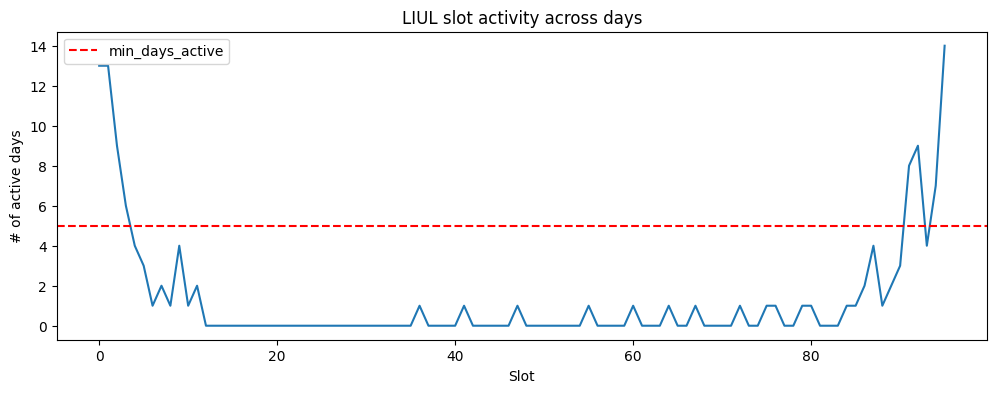

  → Replacing spike 1251.77 W @ 2022-12-20 01:00:00 (raw 1251.77 W)
  → Replacing spike 1267.26 W @ 2022-12-24 01:00:00 (raw 1267.26 W)
  → Replacing spike 1225.32 W @ 2023-01-02 01:00:00 (raw 1225.32 W)
  → Replacing spike 1258.22 W @ 2023-01-29 01:00:00 (raw 1258.22 W)
  → Replacing spike 1266.36 W @ 2022-12-28 01:15:00 (raw 1266.36 W)
  → Replacing spike 1352.37 W @ 2023-02-25 01:15:00 (raw 1352.37 W)
  → Replacing spike 1245.38 W @ 2023-03-04 01:15:00 (raw 1245.38 W)
  → Replacing spike 1193.29 W @ 2022-12-18 01:30:00 (raw 1193.29 W)
  → Replacing spike 1243.30 W @ 2022-12-18 01:45:00 (raw 1243.30 W)
  → Replacing spike 1301.26 W @ 2023-01-27 01:45:00 (raw 1301.26 W)
  → Replacing spike 1239.61 W @ 2023-01-11 02:00:00 (raw 1239.61 W)
  → Replacing spike 1278.46 W @ 2022-11-20 02:15:00 (raw 1278.46 W)
  → Replacing spike 1288.43 W @ 2022-12-08 02:15:00 (raw 1288.43 W)
  → Replacing spike 1275.98 W @ 2022-12-22 02:15:00 (raw 1275.98 W)
  → Replacing spike 1435.89 W @ 2022-12-25 02:15

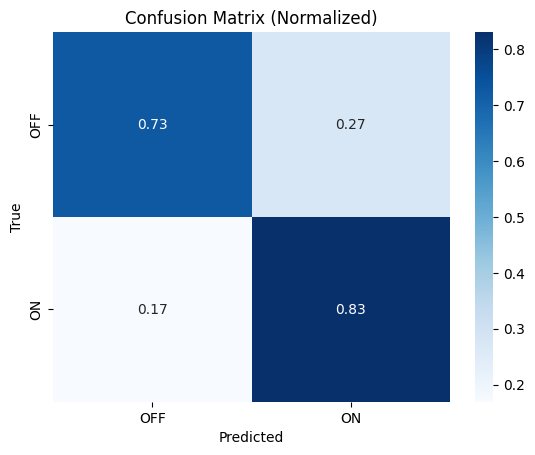

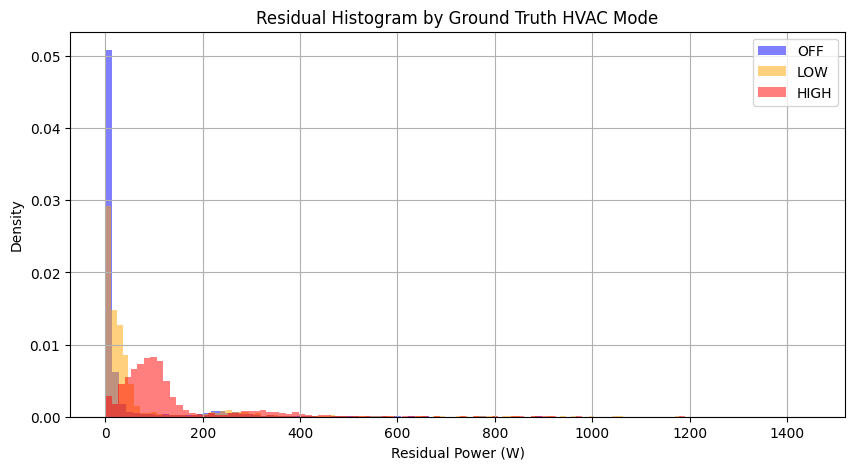

Residual Summary Statistics:
  Mean   : 70.12 W
  Median : 14.83 W
  Std Dev: 138.10 W
  Max    : 1446.91 W


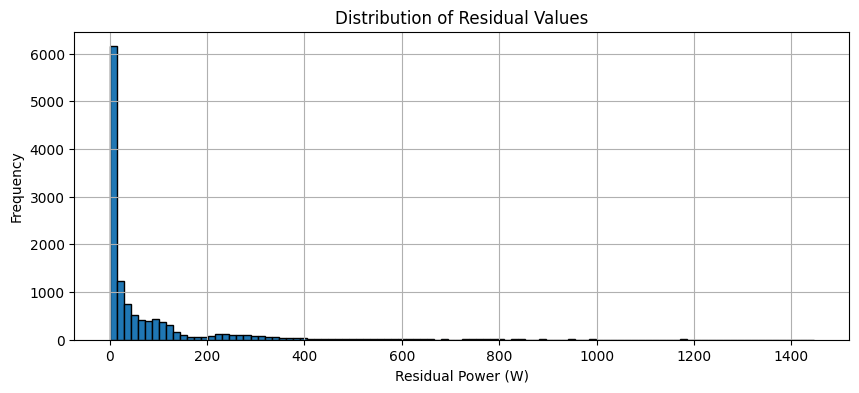

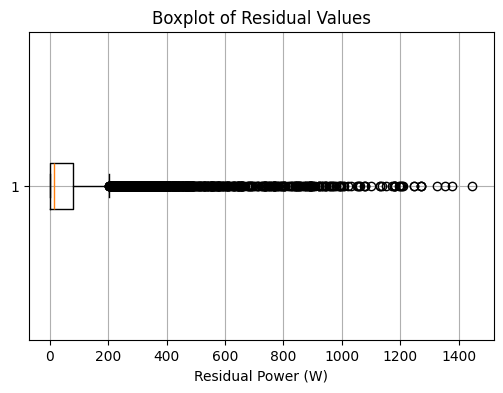

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.84      0.76      0.80      6976
         LOW       0.44      0.44      0.44      2373
        HIGH       0.63      0.76      0.69      3035

    accuracy                           0.70     12384
   macro avg       0.64      0.66      0.64     12384
weighted avg       0.71      0.70      0.70     12384



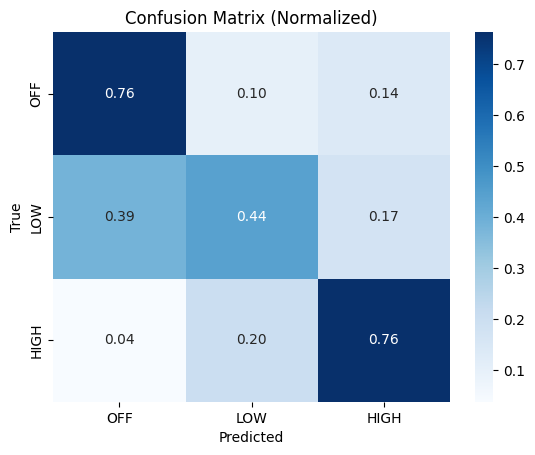

count    96.000000
mean      3.906250
std       3.343739
min       0.000000
25%       1.000000
50%       3.500000
75%       6.000000
max      13.000000
dtype: float64
[ 2  3  2  1  3  3  2  1  0  1  0  0  0  0  1  1  1  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  1  2  5  4  1  3  5  4  8 10  8  9  6  3  3
  3  2  2  6  4  8  5 10  5  7  9  5  4  4  5  7  6  5  6  7  5  5  3  4
  5  4  7  5 10 13  8  8 13  9  9  9 10  8  6  7  4  3  5  3  2  1  4  2]


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


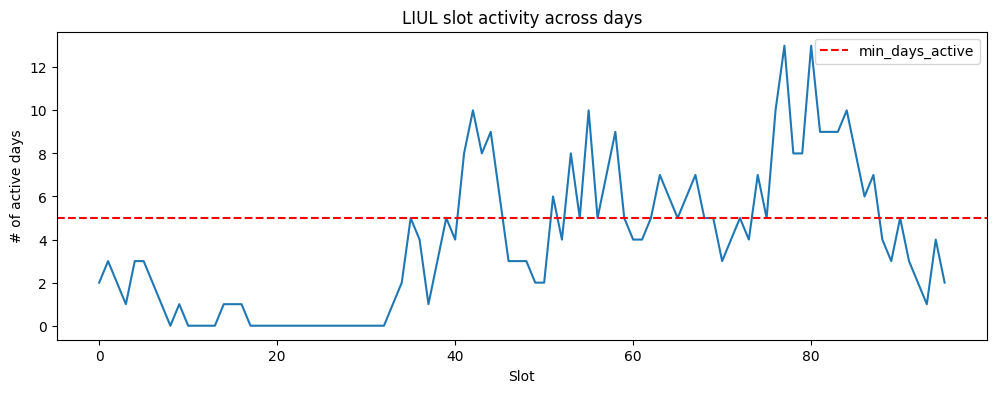

  → Replacing spike 1214.58 W @ 2022-12-09 00:00:00 (raw 1214.58 W)
  → Replacing spike 1469.22 W @ 2023-04-19 00:00:00 (raw 1469.22 W)
  → Replacing spike 1162.77 W @ 2022-10-12 00:15:00 (raw 1162.77 W)
  → Replacing spike 1197.83 W @ 2022-12-09 00:15:00 (raw 1197.83 W)
  → Replacing spike 1368.98 W @ 2023-04-13 00:15:00 (raw 1368.98 W)
  → Replacing spike 1412.96 W @ 2023-04-06 00:30:00 (raw 1412.96 W)
  → Replacing spike 1288.84 W @ 2023-04-13 00:30:00 (raw 1288.84 W)
  → Replacing spike 1311.84 W @ 2023-04-13 00:45:00 (raw 1311.84 W)
  → Replacing spike 1271.56 W @ 2023-03-24 01:00:00 (raw 1271.56 W)
  → Replacing spike 1277.23 W @ 2023-04-13 01:00:00 (raw 1277.23 W)
  → Replacing spike 1133.35 W @ 2023-04-21 01:00:00 (raw 1133.35 W)
  → Replacing spike 1198.15 W @ 2022-11-04 01:15:00 (raw 1198.15 W)
  → Replacing spike 1228.30 W @ 2023-03-24 01:15:00 (raw 1228.30 W)
  → Replacing spike 1287.79 W @ 2023-04-13 01:15:00 (raw 1287.79 W)
  → Replacing spike 1217.85 W @ 2023-03-24 01:30

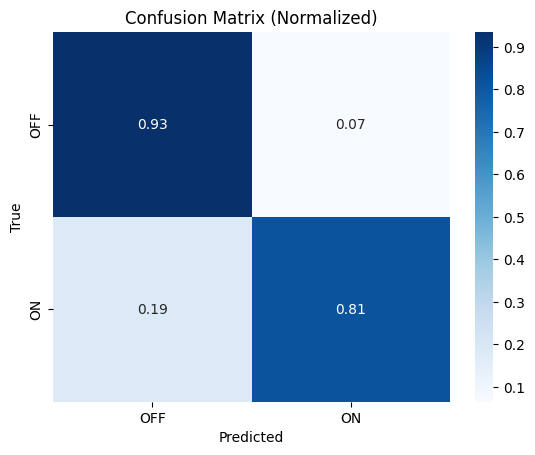

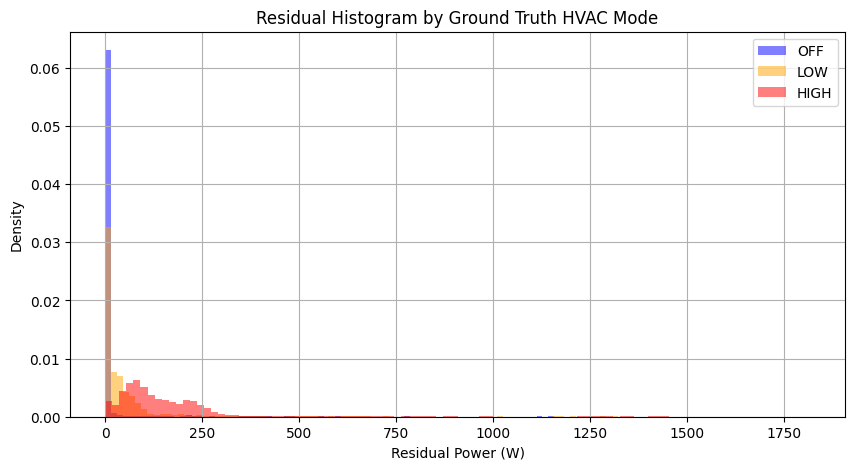

Residual Summary Statistics:
  Mean   : 93.61 W
  Median : 35.34 W
  Std Dev: 178.72 W
  Max    : 1815.34 W


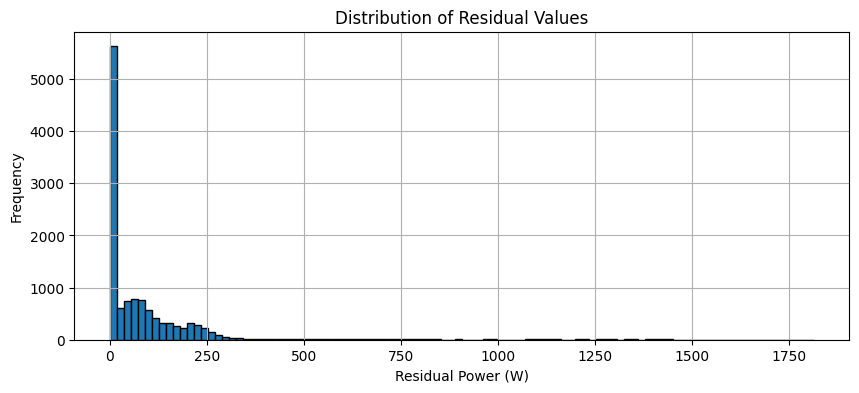

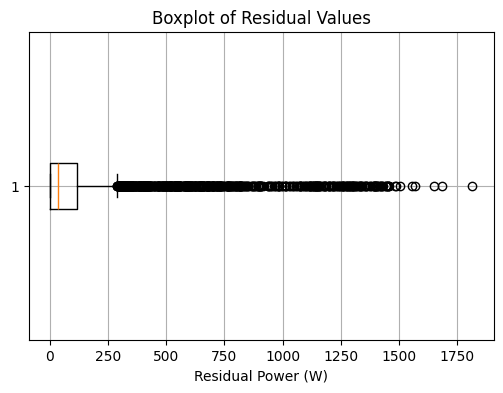

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.71      0.94      0.81      4226
         LOW       0.47      0.28      0.35      2679
        HIGH       0.85      0.80      0.83      5479

    accuracy                           0.74     12384
   macro avg       0.68      0.67      0.66     12384
weighted avg       0.72      0.74      0.72     12384



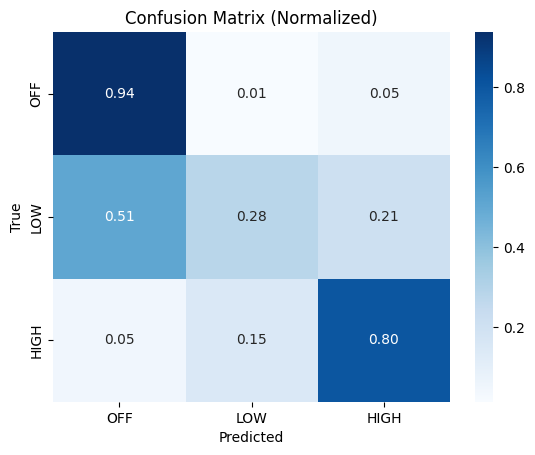

count    96.000000
mean      2.364583
std       2.026767
min       0.000000
25%       0.000000
50%       2.000000
75%       4.000000
max       9.000000
dtype: float64
[5 6 5 4 1 0 0 1 2 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 4 0 1
 2 1 3 3 4 0 3 3 3 3 3 3 3 3 3 3 5 4 5 3 5 6 2 3 1 3 1 1 2 4 5 1 0 1 2 4 2
 3 5 2 5 2 4 4 2 3 5 2 3 5 5 3 4 4 5 8 9 3 4]


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


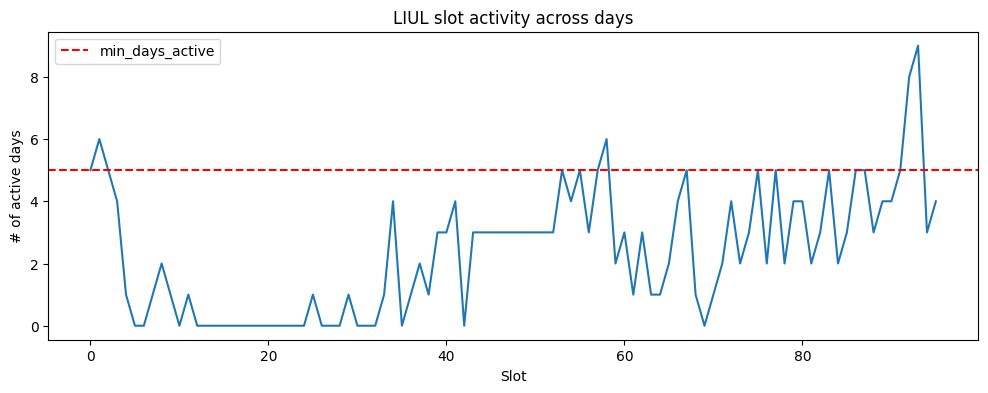

  → Replacing spike 1290.16 W @ 2023-02-24 00:45:00 (raw 1290.16 W)
  → Replacing spike 1595.82 W @ 2023-02-27 00:45:00 (raw 1595.82 W)
  → Replacing spike 1428.42 W @ 2023-03-22 00:45:00 (raw 1428.42 W)
  → Replacing spike 1731.56 W @ 2023-04-03 00:45:00 (raw 1731.56 W)
  → Replacing spike 1254.24 W @ 2023-03-11 01:00:00 (raw 1254.24 W)
  → Replacing spike 1108.84 W @ 2023-04-13 01:45:00 (raw 1108.84 W)
  → Replacing spike 1524.86 W @ 2023-02-15 02:00:00 (raw 1524.86 W)
  → Replacing spike 1216.64 W @ 2023-04-16 02:00:00 (raw 1216.64 W)
  → Replacing spike 1537.24 W @ 2023-03-20 02:15:00 (raw 1537.24 W)
  → Replacing spike 1372.06 W @ 2023-03-18 02:45:00 (raw 1372.06 W)
  → Replacing spike 1152.02 W @ 2022-11-30 06:15:00 (raw 1152.02 W)
  → Replacing spike 1271.71 W @ 2022-11-12 07:15:00 (raw 1271.71 W)
  → Replacing spike 1150.70 W @ 2022-12-02 08:15:00 (raw 1150.70 W)
  → Replacing spike 1140.24 W @ 2022-12-02 08:30:00 (raw 1140.24 W)
  → Replacing spike 1236.71 W @ 2023-03-21 08:30

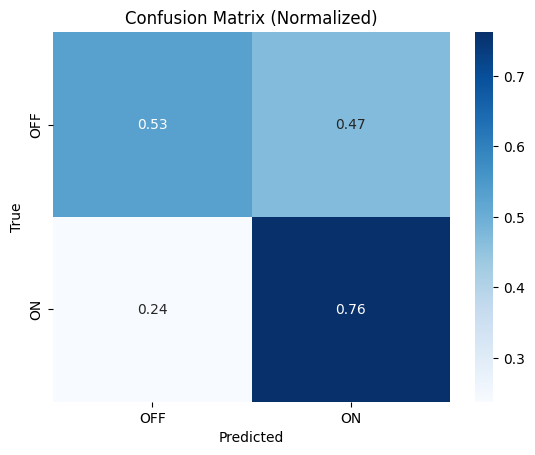

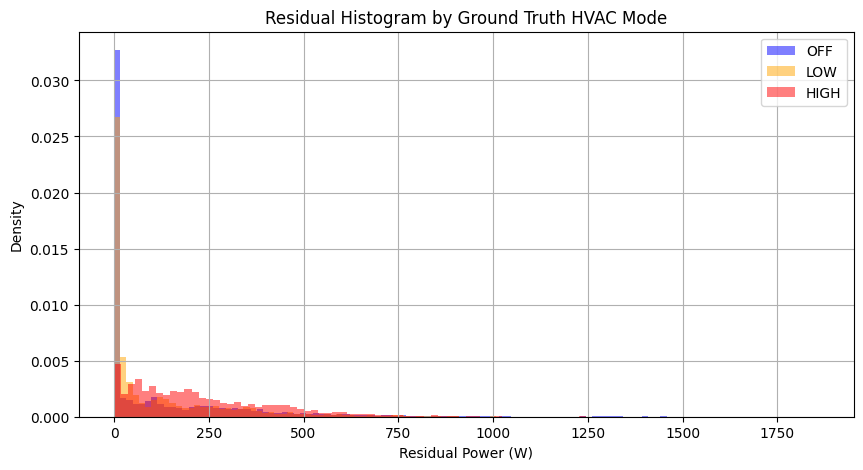

Residual Summary Statistics:
  Mean   : 152.37 W
  Median : 61.89 W
  Std Dev: 206.11 W
  Max    : 1858.53 W


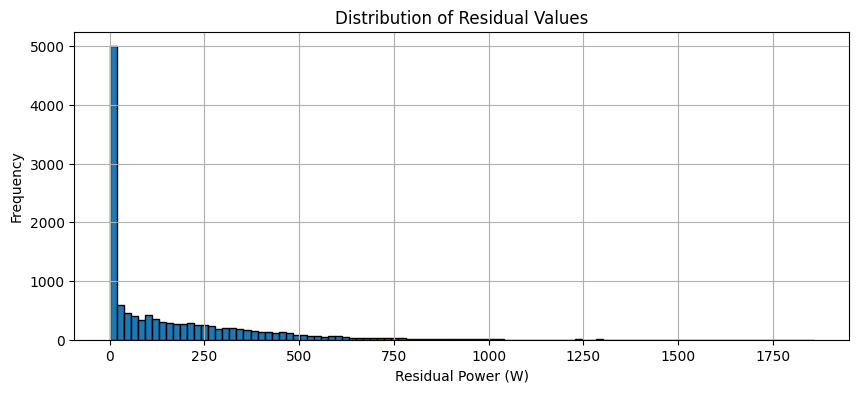

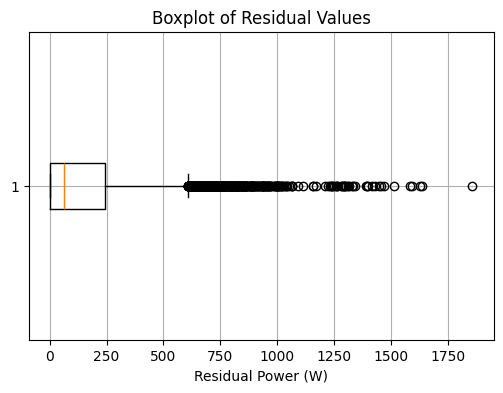

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.67      0.54      0.60      6065
         LOW       0.46      0.18      0.26      3232
        HIGH       0.40      0.81      0.53      3087

    accuracy                           0.51     12384
   macro avg       0.51      0.51      0.46     12384
weighted avg       0.55      0.51      0.49     12384



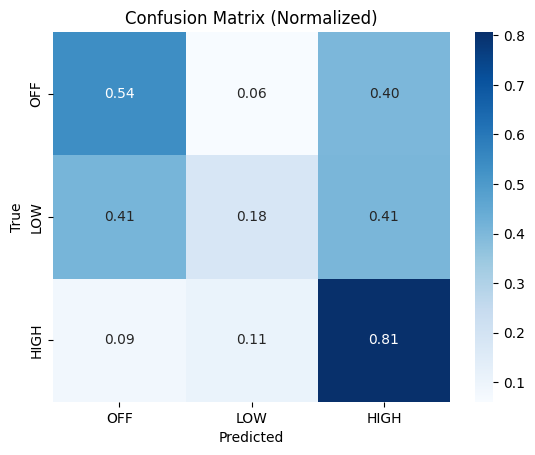

count    96.000000
mean      2.739583
std       2.488901
min       0.000000
25%       1.000000
50%       2.000000
75%       4.000000
max       9.000000
dtype: float64
[3 3 1 1 0 0 1 1 0 1 1 1 0 2 1 1 0 0 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 3 1 0 2
 2 2 0 0 2 2 1 2 3 7 5 4 4 4 3 6 4 7 4 7 8 9 9 9 7 5 5 4 5 3 3 3 6 3 8 8 3
 1 2 2 3 7 5 7 6 3 5 1 1 3 2 2 1 2 2 1 4 3 3]


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


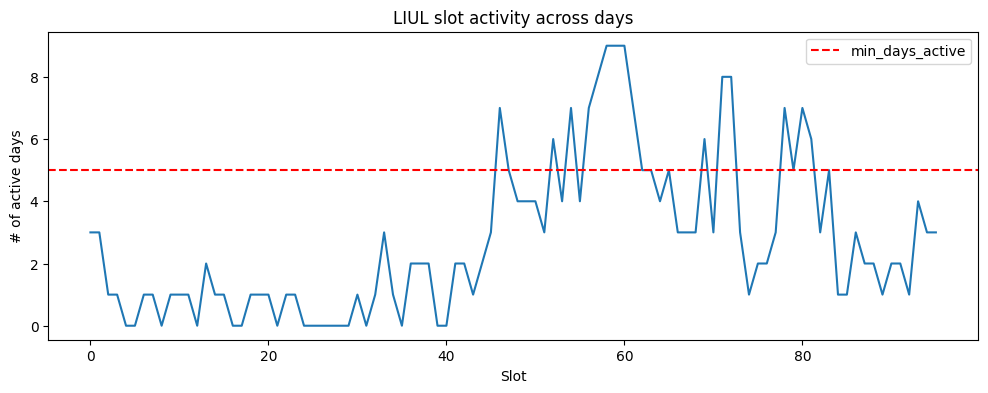

  → Replacing spike 1438.58 W @ 2023-02-28 00:00:00 (raw 1438.58 W)
  → Replacing spike 1299.59 W @ 2023-03-20 00:00:00 (raw 1299.59 W)
  → Replacing spike 1597.39 W @ 2023-04-12 00:00:00 (raw 1597.39 W)
  → Replacing spike 2303.79 W @ 2023-02-19 00:15:00 (raw 2303.79 W)
  → Replacing spike 1284.01 W @ 2023-02-28 00:15:00 (raw 1284.01 W)
  → Replacing spike 1516.88 W @ 2023-03-29 00:15:00 (raw 1516.88 W)
  → Replacing spike 1572.87 W @ 2023-03-23 00:30:00 (raw 1572.87 W)
  → Replacing spike 1336.67 W @ 2023-03-23 00:45:00 (raw 1336.67 W)
  → Replacing spike 1275.06 W @ 2023-04-10 01:30:00 (raw 1275.06 W)
  → Replacing spike 1713.72 W @ 2023-04-10 01:45:00 (raw 1713.72 W)
  → Replacing spike 1735.69 W @ 2023-04-09 02:15:00 (raw 1735.69 W)
  → Replacing spike 1728.02 W @ 2023-04-09 02:30:00 (raw 1728.02 W)
  → Replacing spike 1573.61 W @ 2023-02-17 02:45:00 (raw 1573.61 W)
  → Replacing spike 1806.41 W @ 2023-01-17 03:15:00 (raw 1806.41 W)
  → Replacing spike 1173.83 W @ 2023-04-21 03:15

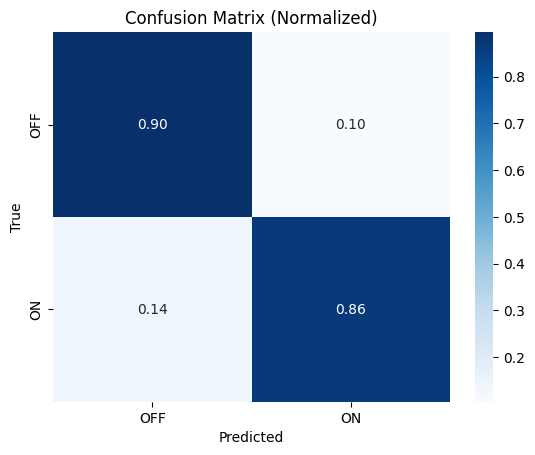

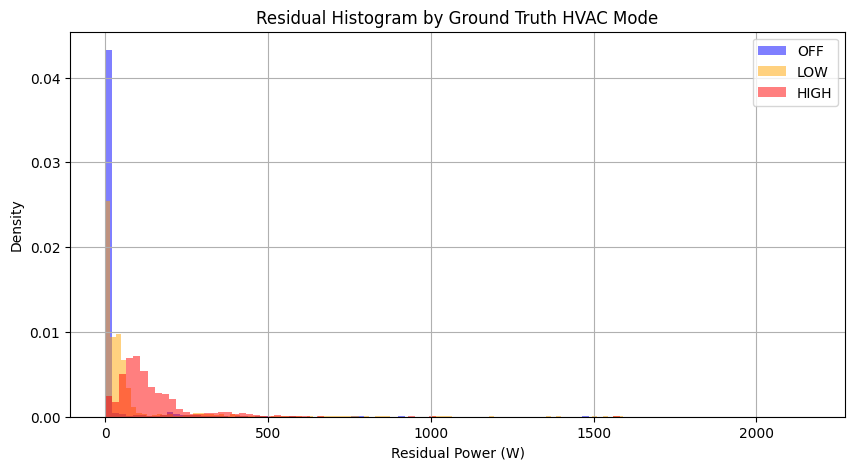

Residual Summary Statistics:
  Mean   : 96.13 W
  Median : 57.46 W
  Std Dev: 158.87 W
  Max    : 2163.99 W


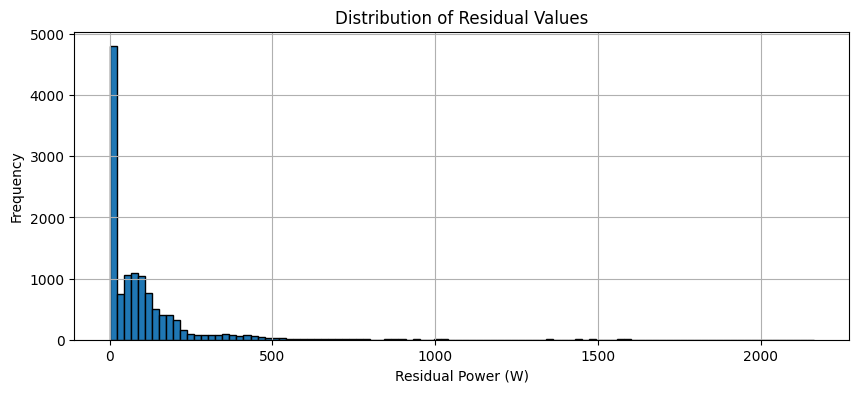

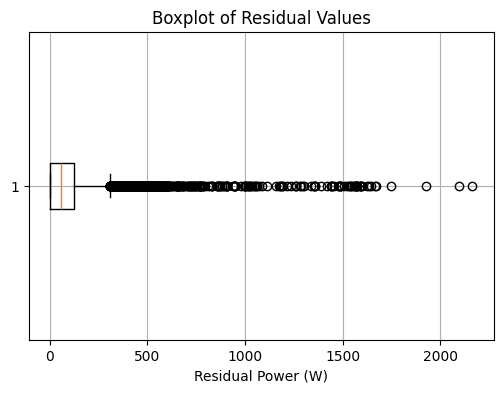

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.73      0.90      0.81      3838
         LOW       0.51      0.39      0.44      2184
        HIGH       0.88      0.83      0.85      6362

    accuracy                           0.77     12384
   macro avg       0.71      0.71      0.70     12384
weighted avg       0.77      0.77      0.77     12384



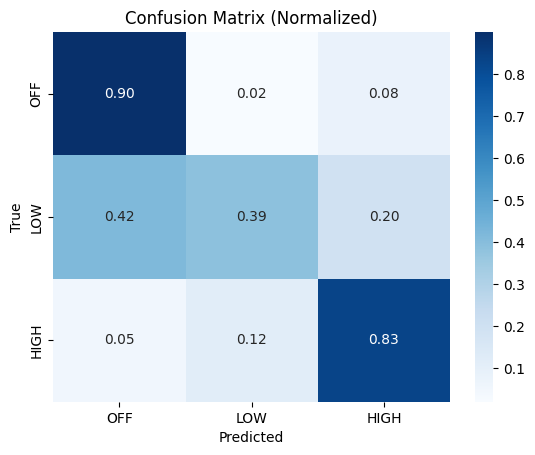

count    96.000000
mean      1.270833
std       2.084929
min       0.000000
25%       0.000000
50%       0.000000
75%       2.000000
max       8.000000
dtype: float64
[2 5 4 2 3 4 4 4 1 1 0 0 0 1 1 1 3 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 2 5 7 2 5 7 3 3 2 4 8 6 7 7 3 5 4]


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


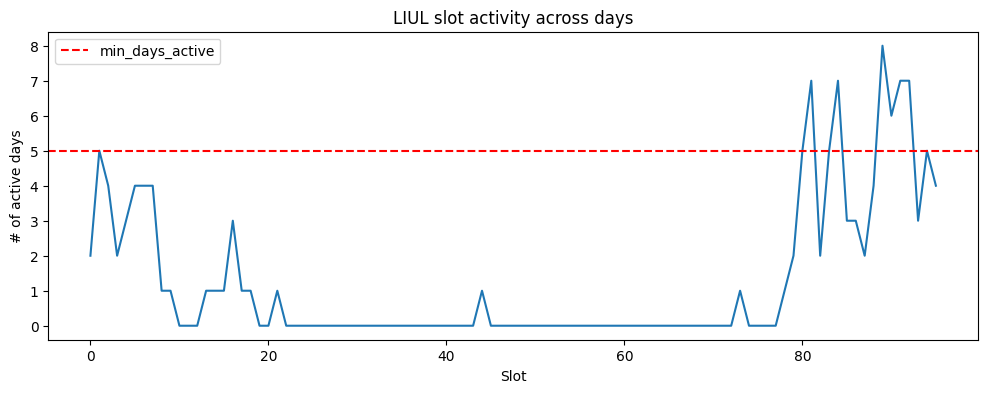

  → Replacing spike 1102.29 W @ 2022-09-19 00:00:00 (raw 1102.29 W)
  → Replacing spike 1250.11 W @ 2023-04-05 00:00:00 (raw 1250.11 W)
  → Replacing spike 1226.78 W @ 2022-09-27 00:30:00 (raw 1226.78 W)
  → Replacing spike 1281.27 W @ 2022-11-14 00:30:00 (raw 1281.27 W)
  → Replacing spike 1144.83 W @ 2023-01-25 00:30:00 (raw 1144.83 W)
  → Replacing spike 1159.37 W @ 2023-03-03 00:30:00 (raw 1159.37 W)
  → Replacing spike 1278.84 W @ 2022-11-14 00:45:00 (raw 1278.84 W)
  → Replacing spike 1223.40 W @ 2023-04-01 00:45:00 (raw 1223.40 W)
  → Replacing spike 1274.19 W @ 2022-11-09 01:00:00 (raw 1274.19 W)
  → Replacing spike 1161.40 W @ 2022-11-14 01:00:00 (raw 1161.40 W)
  → Replacing spike 1127.75 W @ 2023-04-11 01:00:00 (raw 1127.75 W)
  → Replacing spike 1241.25 W @ 2022-10-13 01:15:00 (raw 1241.25 W)
  → Replacing spike 1210.75 W @ 2022-11-14 01:15:00 (raw 1210.75 W)
  → Replacing spike 1222.35 W @ 2023-02-10 01:15:00 (raw 1222.35 W)
  → Replacing spike 1265.41 W @ 2023-04-26 01:15

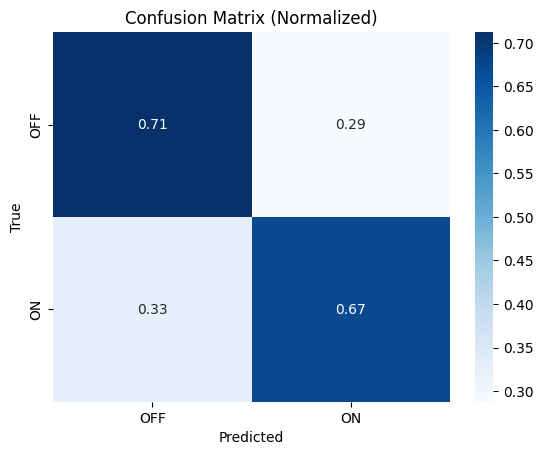

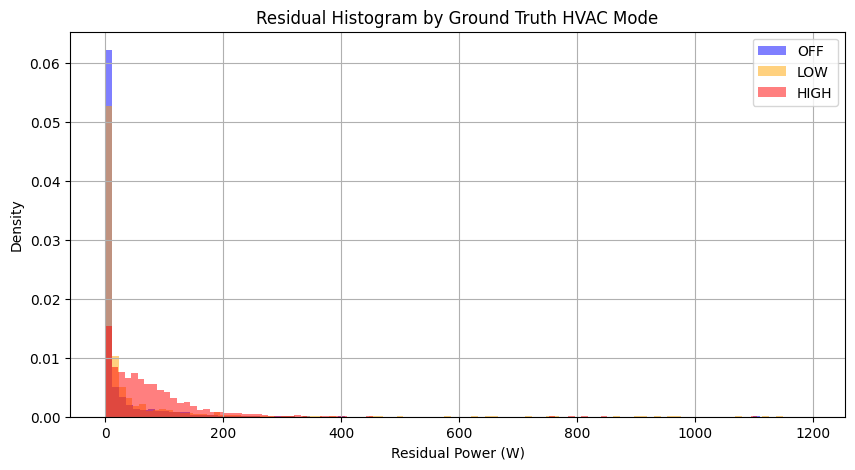

Residual Summary Statistics:
  Mean   : 33.44 W
  Median : 0.00 W
  Std Dev: 90.54 W
  Max    : 1195.19 W


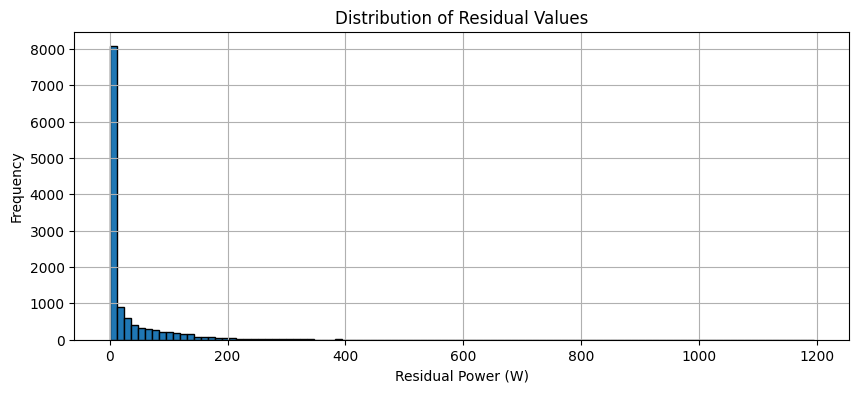

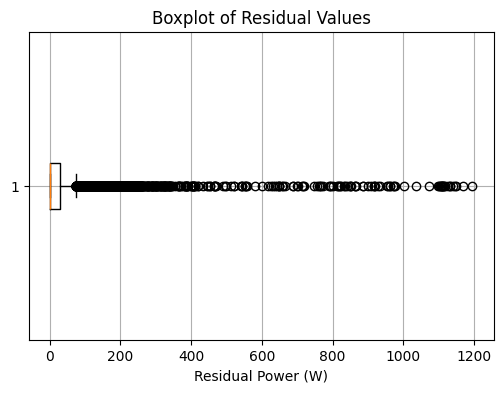

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.86      0.73      0.79      9248
         LOW       0.15      0.24      0.19      1494
        HIGH       0.37      0.47      0.41      1642

    accuracy                           0.64     12384
   macro avg       0.46      0.48      0.46     12384
weighted avg       0.71      0.64      0.67     12384



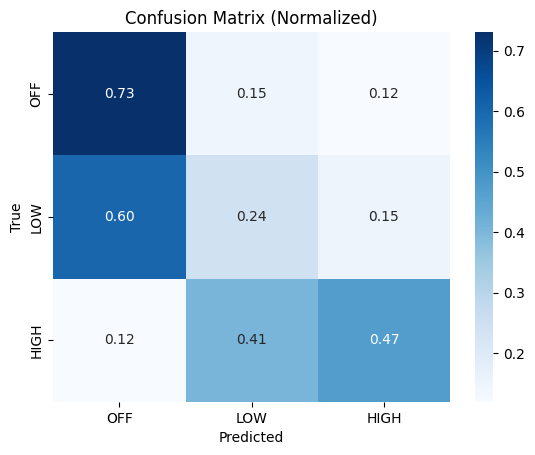

count    96.000000
mean      1.541667
std       1.946206
min       0.000000
25%       0.000000
50%       1.000000
75%       3.000000
max       8.000000
dtype: float64
[0 1 1 1 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 1 1 1 3 0 4 4 0 1 0 2 5 3 5 3 1 0 1 7 2 4 5 3 3 3 4 4 2 1 1 1 1 2
 3 6 3 6 5 4 7 8 4 4 1 1 1 2 0 0 3 1 1 1 0 0]


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


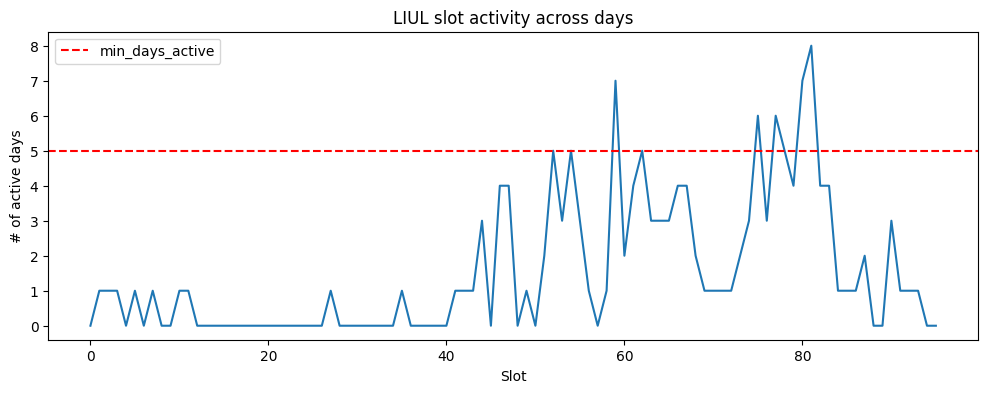

  → Replacing spike 1343.92 W @ 2023-03-28 00:15:00 (raw 1343.92 W)
  → Replacing spike 1428.84 W @ 2023-03-28 00:30:00 (raw 1428.84 W)
  → Replacing spike 1462.23 W @ 2023-03-28 00:45:00 (raw 1462.23 W)
  → Replacing spike 1136.48 W @ 2023-02-27 01:15:00 (raw 1136.48 W)
  → Replacing spike 1262.86 W @ 2023-04-17 01:45:00 (raw 1262.86 W)
  → Replacing spike 1245.90 W @ 2022-12-11 02:30:00 (raw 1245.90 W)
  → Replacing spike 1274.82 W @ 2022-12-11 02:45:00 (raw 1274.82 W)
  → Replacing spike 1193.60 W @ 2022-08-30 06:45:00 (raw 1193.60 W)
  → Replacing spike 1199.61 W @ 2023-03-02 08:45:00 (raw 1199.61 W)
  → Replacing spike 1220.89 W @ 2023-03-06 10:15:00 (raw 1220.89 W)
  → Replacing spike 1229.33 W @ 2023-03-20 10:30:00 (raw 1229.33 W)
  → Replacing spike 1143.97 W @ 2022-09-03 10:45:00 (raw 1143.97 W)
  → Replacing spike 1141.19 W @ 2023-01-18 11:00:00 (raw 1141.19 W)
  → Replacing spike 1224.24 W @ 2023-02-01 11:00:00 (raw 1224.24 W)
  → Replacing spike 1103.67 W @ 2023-02-21 11:00

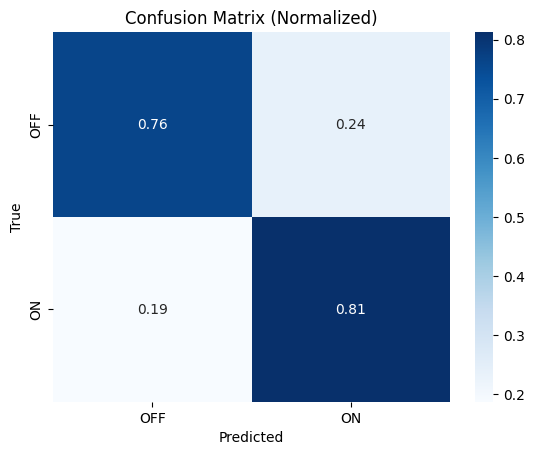

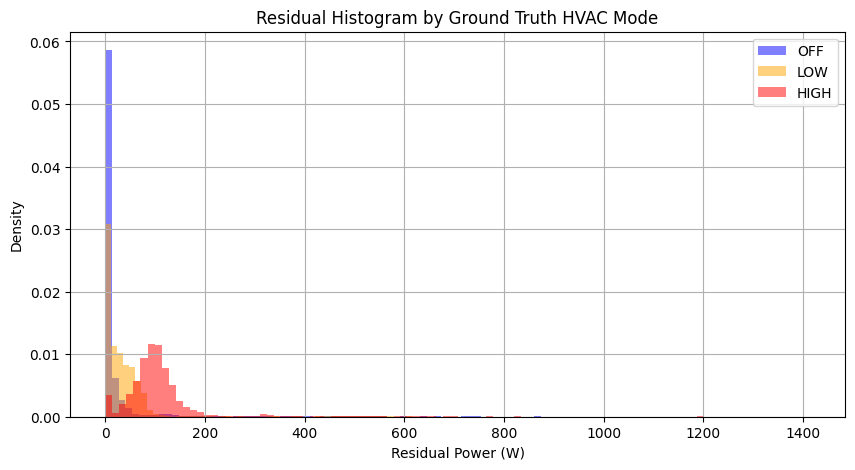

Residual Summary Statistics:
  Mean   : 56.66 W
  Median : 18.99 W
  Std Dev: 108.69 W
  Max    : 1413.73 W


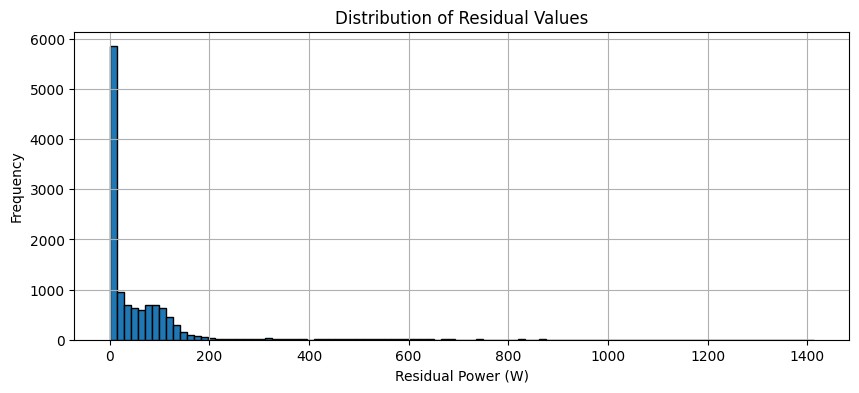

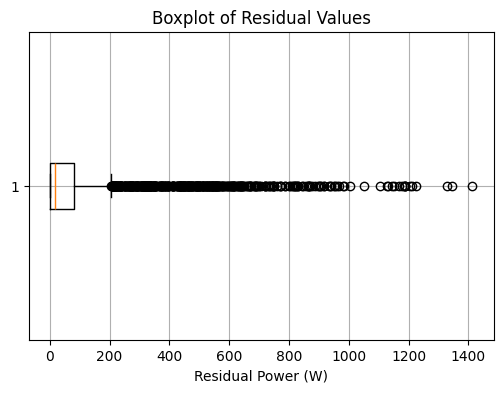

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.76      0.79      0.78      5615
         LOW       0.52      0.43      0.47      3019
        HIGH       0.77      0.84      0.81      3750

    accuracy                           0.72     12384
   macro avg       0.69      0.69      0.69     12384
weighted avg       0.71      0.72      0.71     12384



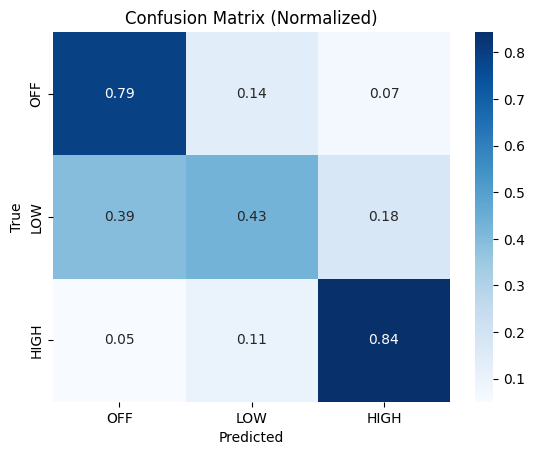

count    96.000000
mean      1.739583
std       2.239571
min       0.000000
25%       0.000000
50%       1.000000
75%       3.000000
max      11.000000
dtype: float64
[ 1  1  0  1  0  1  0  0  0  1  0  1  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  1  1  2  1  0  1  1  0
  1  0  1  2  0  2  2  1  2  2  2  3  1  0  1  0  1  1  1  3  9  5  7  5
  6  7 11  4  5  5  2  4  5  5  3  4  5  4  2  5  4  3  5  2  4  3  2  1]


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


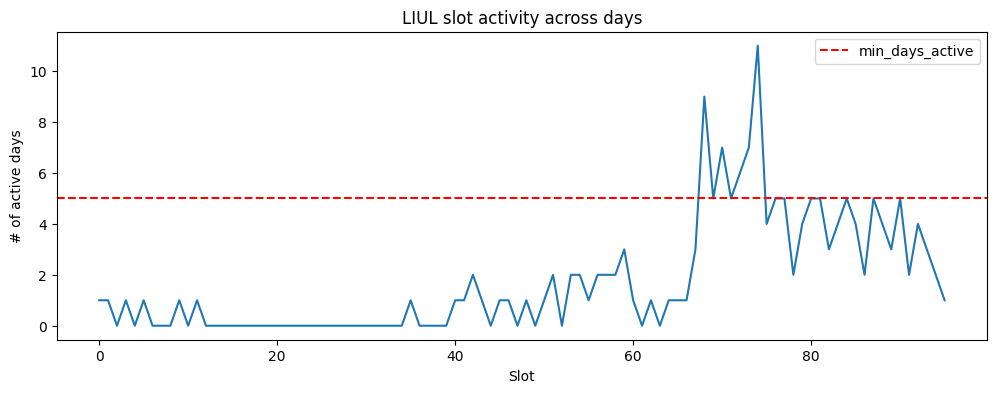

  → Replacing spike 1119.36 W @ 2022-10-31 00:00:00 (raw 1119.36 W)
  → Replacing spike 1105.58 W @ 2022-12-09 00:15:00 (raw 1105.58 W)
  → Replacing spike 1311.90 W @ 2023-03-26 00:45:00 (raw 1311.90 W)
  → Replacing spike 1100.58 W @ 2022-10-28 01:15:00 (raw 1100.58 W)
  → Replacing spike 1267.95 W @ 2022-12-04 02:15:00 (raw 1267.95 W)
  → Replacing spike 1066.09 W @ 2022-12-04 02:45:00 (raw 1066.09 W)
  → Replacing spike 1158.62 W @ 2022-10-03 08:45:00 (raw 1158.62 W)
  → Replacing spike 1248.99 W @ 2022-11-07 10:00:00 (raw 1248.99 W)
  → Replacing spike 1227.33 W @ 2022-11-07 10:15:00 (raw 1227.33 W)
  → Replacing spike 1308.48 W @ 2022-09-28 10:30:00 (raw 1308.48 W)
  → Replacing spike 1238.79 W @ 2022-11-07 10:30:00 (raw 1238.79 W)
  → Replacing spike 1233.89 W @ 2022-11-07 10:45:00 (raw 1233.89 W)
  → Replacing spike 1179.57 W @ 2023-03-28 11:15:00 (raw 1179.57 W)
  → Replacing spike 1186.87 W @ 2022-09-25 11:30:00 (raw 1186.87 W)
  → Replacing spike 1230.71 W @ 2023-02-17 12:00

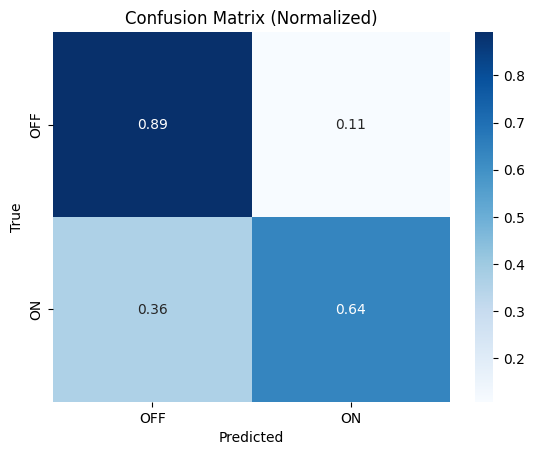

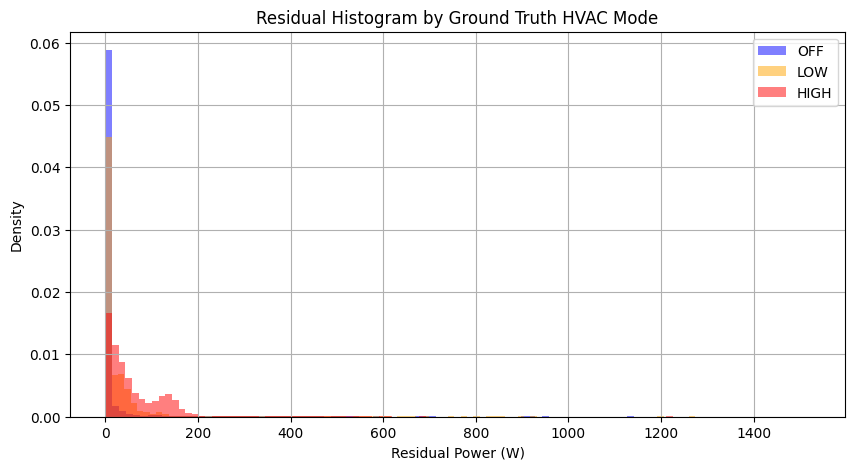

Residual Summary Statistics:
  Mean   : 49.30 W
  Median : 8.68 W
  Std Dev: 117.96 W
  Max    : 1520.95 W


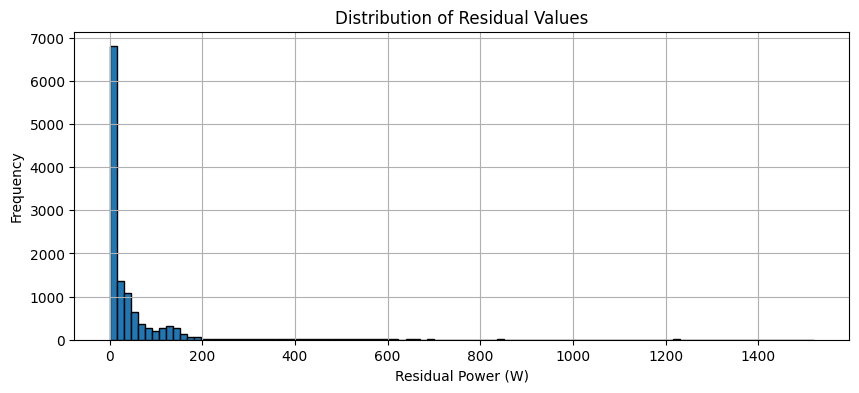

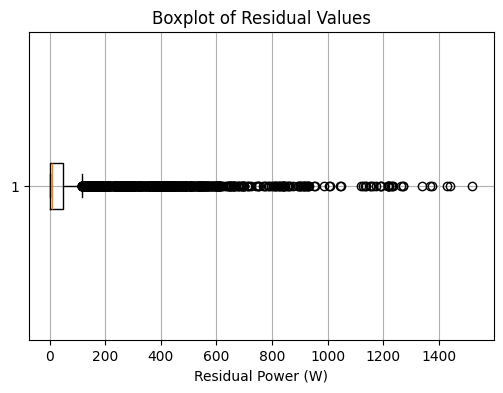

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.48      0.90      0.62      3560
         LOW       0.30      0.25      0.28      3804
        HIGH       0.73      0.36      0.49      5020

    accuracy                           0.48     12384
   macro avg       0.50      0.50      0.46     12384
weighted avg       0.53      0.48      0.46     12384



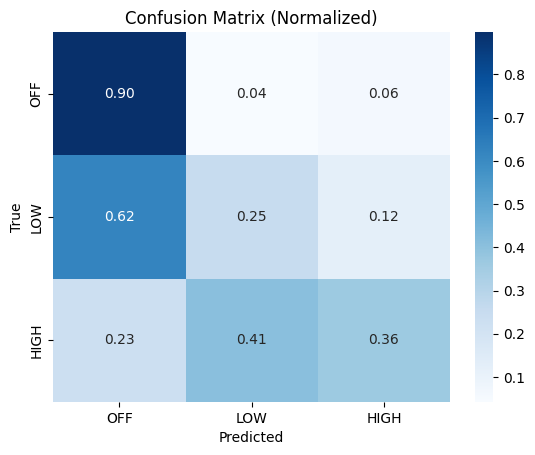

count    96.000000
mean      2.468750
std       2.741314
min       0.000000
25%       0.000000
50%       1.000000
75%       4.000000
max      12.000000
dtype: float64
[ 1  1  0  0  0  0  1  1  1  0  1  0  0  1  1  1  0  0  0  0  0  0  0  0
  0  0  0  0  0  1  0  0  0  0  0  1  1  0  0  0  1  7  5  7  5  3  5  5
  6  2  2  4  3  6  3  6  3  5  3  5  0  1  2  0  1  2  4  4  4  5  2  1
  4  5 10  7  6  9 12 10  5  6  7  4  4  2  1  2  7  1  2  2  2  2  2  1]


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16812\654097981.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


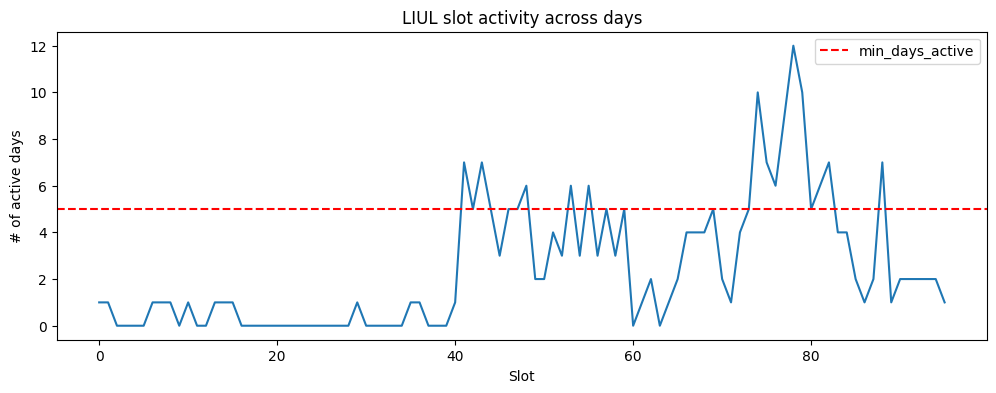

  → Replacing spike 1320.42 W @ 2023-04-28 00:00:00 (raw 1320.42 W)
  → Replacing spike 1316.80 W @ 2023-04-20 00:15:00 (raw 1316.80 W)
  → Replacing spike 1265.05 W @ 2022-10-02 01:30:00 (raw 1265.05 W)
  → Replacing spike 1296.05 W @ 2022-10-02 01:45:00 (raw 1296.05 W)
  → Replacing spike 1198.91 W @ 2022-10-02 02:00:00 (raw 1198.91 W)
  → Replacing spike 1253.38 W @ 2023-03-19 02:30:00 (raw 1253.38 W)
  → Replacing spike 1244.95 W @ 2022-10-09 03:15:00 (raw 1244.95 W)
  → Replacing spike 1224.72 W @ 2022-10-09 03:30:00 (raw 1224.72 W)
  → Replacing spike 1218.83 W @ 2022-10-09 03:45:00 (raw 1218.83 W)
  → Replacing spike 1306.52 W @ 2023-02-11 07:15:00 (raw 1306.52 W)
  → Replacing spike 1243.92 W @ 2023-02-28 08:45:00 (raw 1243.92 W)
  → Replacing spike 1258.40 W @ 2023-02-28 09:00:00 (raw 1258.40 W)
  → Replacing spike 1309.03 W @ 2023-02-27 10:00:00 (raw 1309.03 W)
  → Replacing spike 1211.48 W @ 2022-11-08 11:15:00 (raw 1211.48 W)
  → Replacing spike 1202.59 W @ 2022-11-30 11:15

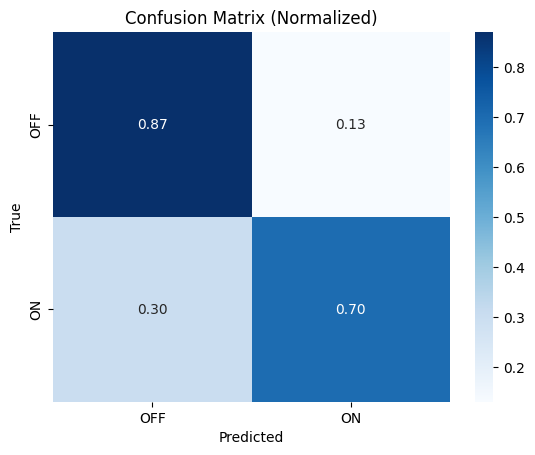

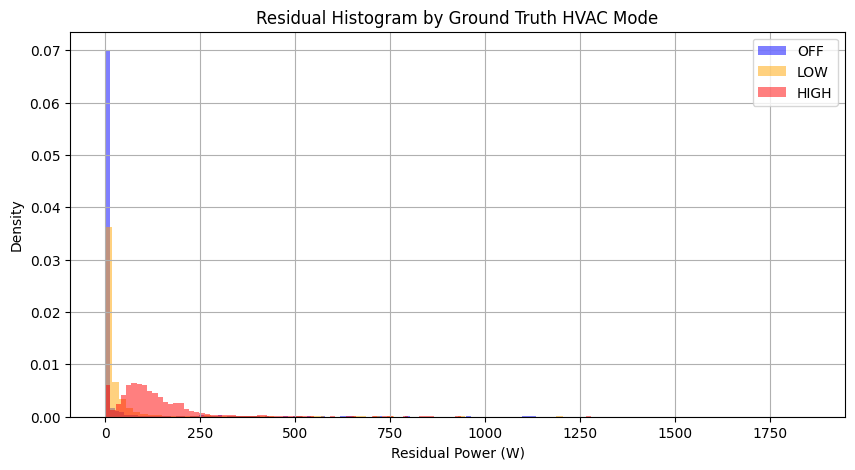

Residual Summary Statistics:
  Mean   : 90.26 W
  Median : 44.47 W
  Std Dev: 154.22 W
  Max    : 1855.77 W


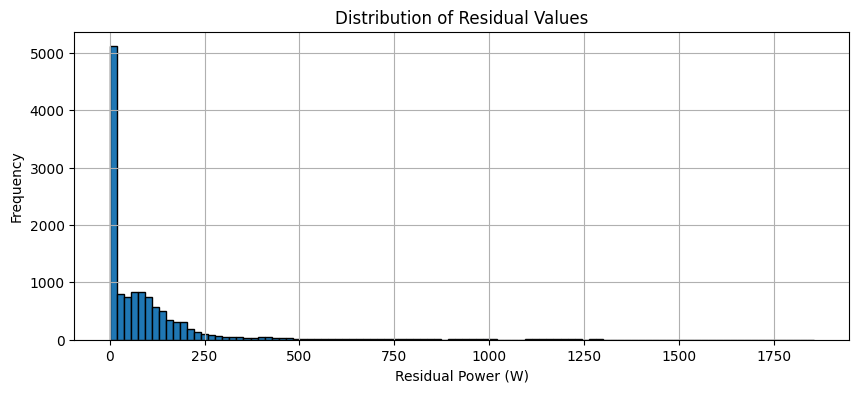

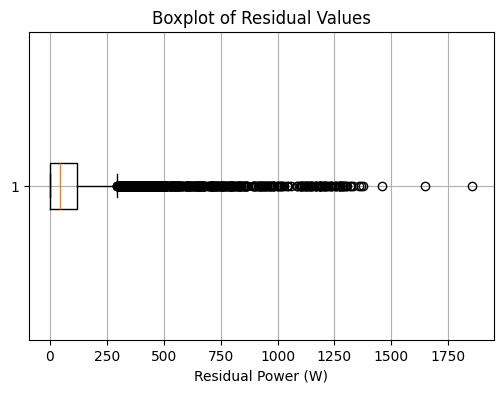

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.34      0.88      0.49      1954
         LOW       0.50      0.21      0.30      4260
        HIGH       0.87      0.78      0.82      6170

    accuracy                           0.60     12384
   macro avg       0.57      0.62      0.54     12384
weighted avg       0.66      0.60      0.59     12384



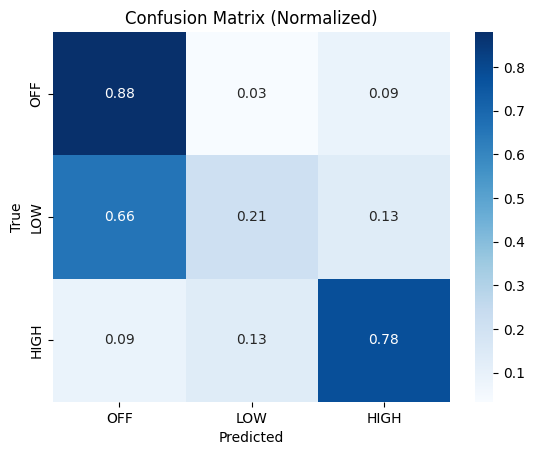

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def make_daily_profiles(df, load_col='total_energy'):
    df = df.copy()
    df[load_col] = df[load_col].fillna(method='ffill')
    df['day'] = df.index.floor('D')
    df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)
    daily = df.pivot(index='day', columns='slot', values=load_col)
    return daily.dropna()

def classify_days_by_temp(df, temp_col='Tout', low_pct=35, high_pct=85):
    daily_temp = df[temp_col].resample('D').mean()
    t_low, t_high = np.percentile(daily_temp.dropna(), [low_pct, high_pct])
    mild_days = daily_temp[(daily_temp >= t_low) & (daily_temp <= t_high)].index
    hvac_days = daily_temp.index.difference(mild_days)
    return list(mild_days), list(hvac_days), t_low, t_high

def extract_simple_residual(df, daily_profiles, mild_days, hvac_days, t_low, t_high, temp_col='Tout'):
    baseline = daily_profiles.loc[mild_days].median(axis=0).values
    residuals = []
    kept_days = []

    for day in hvac_days:
        if day not in daily_profiles.index:
            continue

        profile = daily_profiles.loc[day].values
        Tout = df[temp_col].loc[day : day + pd.Timedelta(days=1)].values[:96]

        hvac_active_mask = (Tout < t_low) | (Tout > t_high)
        if not hvac_active_mask.any():
            continue  

        resid = np.zeros(96)
        resid[hvac_active_mask] = np.clip(profile - baseline, a_min=0, a_max=None)[hvac_active_mask]
        residuals.append(resid)
        kept_days.append(day)

    return np.vstack(residuals), kept_days

def build_ground_truth_matrix(df, days, col='hvac_mode'):
    df['hvac_binary'] = df[col].isin([1, 2]).astype(int)
    gt_matrix = []
    for day in days:
        values = df['hvac_binary'].loc[day: day + pd.Timedelta(days=1)].values[:96]
        if len(values) == 96:
            gt_matrix.append(values)
    return np.vstack(gt_matrix)

def binarify_residuals(resids, threshold_ratio=0.1):
    return (resids > threshold_ratio * resids.max(axis=1, keepdims=True)).astype(int)

def evaluate(pred, true):
    print("→ Classification Report:")
    print(classification_report(true.flatten(), pred.flatten(), target_names=["OFF", "ON"]))
    
    cm = confusion_matrix(true.flatten(), pred.flatten(), normalize='true')
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=["OFF", "ON"], yticklabels=["OFF", "ON"])
    plt.title("Confusion Matrix (Normalized)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

def liul_filter(daily_profiles,
                power_thresh    = 1000,
                min_days_active = 5,
                fill_with       ='baseline'):
    
    baseline   = daily_profiles.median(axis=0)                  
    resid      = (daily_profiles - baseline).clip(lower=0)
    active     = resid.gt(power_thresh)
    days_used  = active.sum(axis=0)                             
    liul_slots = days_used[days_used < min_days_active].index
    print(days_used.describe())
    print(days_used.values)
    plt.figure(figsize=(12, 4))
    plt.plot(days_used.values)
    plt.axhline(min_days_active, color='r', linestyle='--', label='min_days_active')
    plt.title("LIUL slot activity across days")
    plt.xlabel("Slot")
    plt.ylabel("# of active days")
    plt.legend()
    plt.show()
    if fill_with=='baseline':
        for slot in liul_slots:
            for day in daily_profiles.index:
                if resid.at[day, slot] > power_thresh:
                    ts      = day + pd.Timedelta(minutes=15*slot)
                    orig_dp = daily_profiles.at[day, slot]
                    orig_df = df['total_energy'].at[ts]
                    print(f"  → Replacing spike {orig_dp:.2f} W @ {ts} (raw {orig_df:.2f} W)")
                    if fill_with=='baseline':
                        daily_profiles.at[day, slot] = baseline[slot]
                    else:
                        daily_profiles.at[day, slot] = 0
    else:
        daily_profiles.loc[:, liul_slots] = 0
    
    print(f"Total LIUL slots replaced: {len(liul_slots)}")

    return daily_profiles

def classify_residuals_ternary(resids, threshold_ratio=0.015, high_thresh=200):
    row_max = resids.max(axis=1, keepdims=True)
    active_mask = resids > threshold_ratio * row_max

    # Initialize with zeros (OFF)
    ternary = np.zeros_like(resids, dtype=int)

    # Assign 1 (LOW) where active and not exceeding high threshold
    low_mask = (active_mask) & (resids < high_thresh)
    ternary[low_mask] = 1

    # Assign 2 (HIGH) where residuals exceed high threshold
    high_mask = (active_mask) & (resids >= high_thresh)
    ternary[high_mask] = 2

    return ternary

def build_ternary_ground_truth_matrix(df, days, col='hvac_mode'):
    """
    Builds a matrix of shape (len(days), 96) with values 0, 1, or 2 from `hvac_mode` column.
    """
    gt_matrix = []
    for day in days:
        values = df[col].loc[day: day + pd.Timedelta(days=1)].values[:96]
        if len(values) == 96:
            gt_matrix.append(values)
    return np.vstack(gt_matrix)


def evaluate_ternary(pred, true):
    labels = [0, 1, 2]
    names = ["OFF", "LOW", "HIGH"]
    
    print("→ Multiclass Classification Report:")
    print(classification_report(true.flatten(), pred.flatten(), labels=labels, target_names=names))

    cm = confusion_matrix(true.flatten(), pred.flatten(), labels=labels, normalize='true')
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=names, yticklabels=names)
    plt.title("Confusion Matrix (Normalized)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

for df in dfs:
    daily_profiles = make_daily_profiles(df, load_col='total_energy')
    daily_profiles = liul_filter(daily_profiles, power_thresh=1000, min_days_active=5, fill_with='baseline')

    mild_days, hvac_days, t_low, t_high = classify_days_by_temp(df, temp_col='Tout')

    residual_matrix, kept_days = extract_simple_residual(df, daily_profiles, mild_days, hvac_days, t_low, t_high)

    GT_binary = build_ground_truth_matrix(df, kept_days)

    PHVAC_binary = binarify_residuals(residual_matrix,  threshold_ratio=0.015)
    PHVAC_ternary = classify_residuals_ternary(residual_matrix, threshold_ratio=0.02, high_thresh=60)
    GT_ternary = build_ternary_ground_truth_matrix(df, kept_days)


    print(daily_profiles)
    evaluate(PHVAC_binary, GT_binary)

    # Flatten the residuals to 1D for overall distribution
    flat_resids = residual_matrix.flatten()
    flat_truths = GT_ternary.flatten()

    off_mask  = flat_truths == 0
    low_mask  = flat_truths == 1
    high_mask = flat_truths == 2

    plt.figure(figsize=(10, 5))
    plt.hist(flat_resids[off_mask],  bins=100, alpha=0.5, label='OFF',  color='blue', density=True)
    plt.hist(flat_resids[low_mask],  bins=100, alpha=0.5, label='LOW',  color='orange', density=True)
    plt.hist(flat_resids[high_mask], bins=100, alpha=0.5, label='HIGH', color='red', density=True)

    plt.title("Residual Histogram by Ground Truth HVAC Mode")
    plt.xlabel("Residual Power (W)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Residual Summary Statistics:")
    print(f"  Mean   : {np.mean(flat_resids):.2f} W")
    print(f"  Median : {np.median(flat_resids):.2f} W")
    print(f"  Std Dev: {np.std(flat_resids):.2f} W")
    print(f"  Max    : {np.max(flat_resids):.2f} W")

    # Histogram
    plt.figure(figsize=(10, 4))
    plt.hist(flat_resids, bins=100, edgecolor='black')
    plt.title("Distribution of Residual Values")
    plt.xlabel("Residual Power (W)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.boxplot(flat_resids, vert=False, showfliers=True)
    plt.title("Boxplot of Residual Values")
    plt.xlabel("Residual Power (W)")
    plt.grid(True)
    plt.show()

    evaluate_ternary(PHVAC_ternary, GT_ternary)


In [103]:
false_and_mode_0 = df[(df['heat_pump_active'] == False) & (df['hvac_mode'] == 0)].shape[0]

# Count of True heat_pump_active where hvac_mode in [1, 2]
true_and_mode_1_or_2 = df[(df['heat_pump_active'] == True) & (df['hvac_mode'].isin([1, 2]))].shape[0]

print(f"False with hvac_mode == 0: {false_and_mode_0}")
print(f"True with hvac_mode in [1, 2]: {true_and_mode_1_or_2}")

false_and_mode_1_or_2 = df[(df['heat_pump_active'] == False) & (df['hvac_mode'].isin([1, 2]))].shape[0]

# Mismatches where heat_pump_active is True but hvac_mode is 0
true_and_mode_0 = df[(df['heat_pump_active'] == True) & (df['hvac_mode'] == 0)].shape[0]

print(f"False but hvac_mode in [1, 2]: {false_and_mode_1_or_2}")
print(f"True but hvac_mode == 0: {true_and_mode_0}")

KeyError: 'heat_pump_active'

In [131]:
def make_daily_profiles(df, load_col='total_energy'):
    tmp = df[[load_col]].copy()
    tmp['day']  = tmp.index.floor('D')
    tmp['slot'] = ((tmp.index - tmp['day']) / pd.Timedelta('15T')).astype(int)
    daily = tmp.pivot(index='day', columns='slot', values=load_col)
    print(f"Daily profiles shape: {daily.shape} (days, slots)")
    print(f"Number of days: {len(daily)}, slots per day: {daily.shape[1]}")
    assert daily.shape[1] == 96, "Each day must have exactly 96 slots (15-minute data)"

    # Debug: Show stats
    print(daily.describe().T[['mean', 'std', 'min', 'max']].head())

    plt.figure(figsize=(10, 4))
    for i, row in daily.head(3).iterrows():
        plt.plot(row.values, label=str(i.date()))
    plt.title(f"Sample {3} Daily Profiles")
    plt.xlabel("15-minute slot")
    plt.ylabel(load_col)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return daily.dropna()

def liul_filter(daily_profiles,
                power_thresh    = 1000,
                min_days_active = 5,
                fill_with       ='baseline'):
    
    baseline   = daily_profiles.median(axis=0)                  
    resid      = (daily_profiles - baseline).clip(lower=0)
    active     = resid.gt(power_thresh)
    days_used  = active.sum(axis=0)                             
    liul_slots = days_used[days_used < min_days_active].index
    print(days_used.describe())
    print(days_used.values)
    plt.figure(figsize=(12, 4))
    plt.plot(days_used.values)
    plt.axhline(min_days_active, color='r', linestyle='--', label='min_days_active')
    plt.title("LIUL slot activity across days")
    plt.xlabel("Slot")
    plt.ylabel("# of active days")
    plt.legend()
    plt.show()
    if fill_with=='baseline':
        for slot in liul_slots:
            for day in daily_profiles.index:
                if resid.at[day, slot] > power_thresh:
                    ts      = day + pd.Timedelta(minutes=15*slot)
                    orig_dp = daily_profiles.at[day, slot]
                    orig_df = df['total_energy'].at[ts]
                    print(f"  → Replacing spike {orig_dp:.2f} W @ {ts} (raw {orig_df:.2f} W)")
                    if fill_with=='baseline':
                        daily_profiles.at[day, slot] = baseline[slot]
                    else:
                        daily_profiles.at[day, slot] = 0
    else:
        daily_profiles.loc[:, liul_slots] = 0
    
    print(f"Total LIUL slots replaced: {len(liul_slots)}")

    return daily_profiles


Daily profiles shape: (269, 96) (days, slots)
Number of days: 269, slots per day: 96
            mean         std  min          max
slot                                          
0     287.405883  344.028858  0.0  1373.086185
1     287.228830  338.137991  0.0  1371.375699
2     232.905510  280.601580  0.0  1397.808528
3     198.128427  252.529117  0.0  1516.608499
4     193.881324  241.888551  0.0  1267.256808


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_10420\1273513504.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_10420\1285476208.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  tmp['slot'] = ((tmp.index - tmp['day']) / pd.Timedelta('15T')).astype(int)


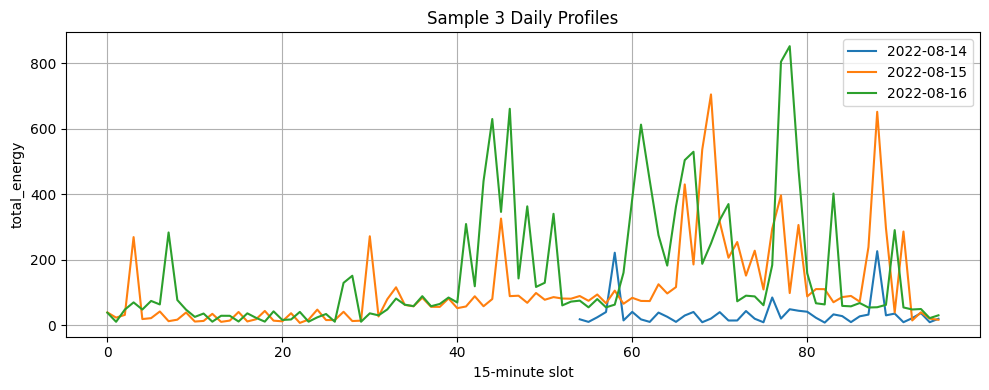

count    96.000000
mean      1.343750
std       2.980032
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max      15.000000
dtype: float64
[13 15  9  6  4  3  1  2  1  4  1  2  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  1  0  0  0  0  0  1
  0  0  0  0  0  0  0  1  0  0  0  0  1  0  0  0  1  0  0  1  0  0  0  0
  1  0  0  1  1  0  0  1  1  0  0  0  1  1  2  4  1  2  3  8  9  4  7 14]


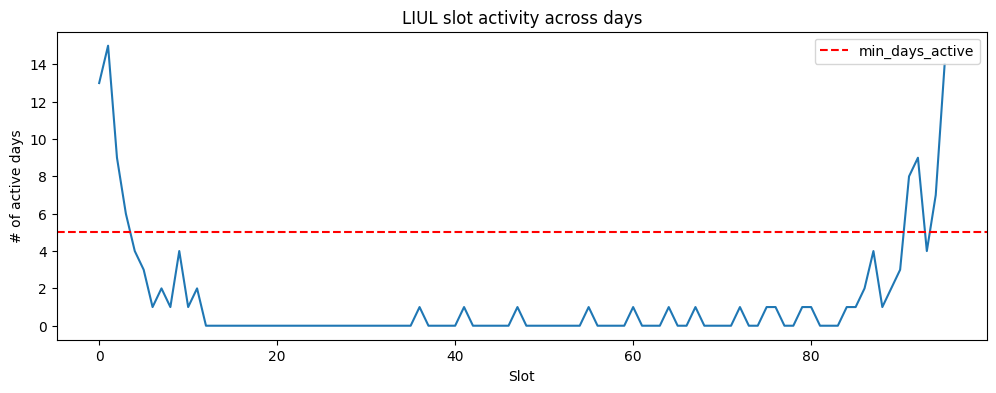

  → Replacing spike 1251.77 W @ 2022-12-20 01:00:00 (raw 1251.77 W)
  → Replacing spike 1267.26 W @ 2022-12-24 01:00:00 (raw 1267.26 W)
  → Replacing spike 1225.32 W @ 2023-01-02 01:00:00 (raw 1225.32 W)
  → Replacing spike 1258.22 W @ 2023-01-29 01:00:00 (raw 1258.22 W)
  → Replacing spike 1266.36 W @ 2022-12-28 01:15:00 (raw 1266.36 W)
  → Replacing spike 1352.37 W @ 2023-02-25 01:15:00 (raw 1352.37 W)
  → Replacing spike 1245.38 W @ 2023-03-04 01:15:00 (raw 1245.38 W)
  → Replacing spike 1193.29 W @ 2022-12-18 01:30:00 (raw 1193.29 W)
  → Replacing spike 1243.30 W @ 2022-12-18 01:45:00 (raw 1243.30 W)
  → Replacing spike 1301.26 W @ 2023-01-27 01:45:00 (raw 1301.26 W)
  → Replacing spike 1239.61 W @ 2023-01-11 02:00:00 (raw 1239.61 W)
  → Replacing spike 1278.46 W @ 2022-11-20 02:15:00 (raw 1278.46 W)
  → Replacing spike 1288.43 W @ 2022-12-08 02:15:00 (raw 1288.43 W)
  → Replacing spike 1275.98 W @ 2022-12-22 02:15:00 (raw 1275.98 W)
  → Replacing spike 1435.89 W @ 2022-12-25 02:15

In [132]:
df.fillna(method='ffill', inplace=True)
daily_profiles = make_daily_profiles(df, load_col='total_energy')

daily_profiles = liul_filter(
    daily_profiles,
    power_thresh    = 1000,   
    min_days_active = 5,     
    fill_with       ='baseline'  
)
daily_profiles = daily_profiles.drop(daily_profiles.index[[0, -1]])
first_day = df.index.min().floor('D')
last_day  = df.index.max().floor('D')

df = df[~df.index.floor('D').isin([first_day, last_day])]
print(daily_profiles.shape)


Temperature thresholds: 3.62 °C (low), 15.87 °C (high)
Found 119 mild days, 148 hvac days


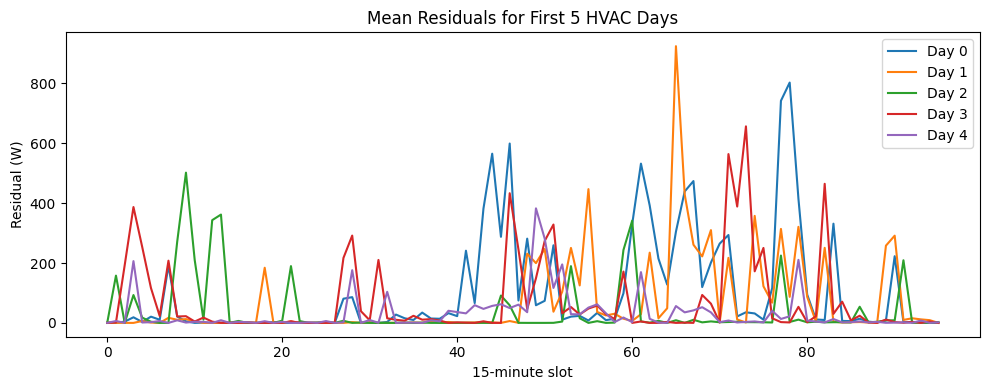

P_mild shape: (96, 20), P_hvac shape: (96, 147)
Computed 147 residual matrices (one per hvac day)


In [133]:
t_low, t_high = 0,0

def classify_days_by_temp(df, temp_col='Tout', low_pct=20, high_pct=80):
    daily_temp = df[temp_col].resample('D').mean()
    
    t_low, t_high = np.percentile(daily_temp.dropna(), [low_pct, high_pct])
    print(f"Temperature thresholds: {t_low:.2f} °C (low), {t_high:.2f} °C (high)")
    mild_days = daily_temp[(daily_temp >= t_low) & (daily_temp <= t_high)].index
    hvac_days  = daily_temp.index.difference(mild_days)
    
    return list(mild_days), list(hvac_days), t_low, t_high

def build_matrices_and_residuals(daily_profiles, mild_days, hvac_days):
    available = set(daily_profiles.index)
    mild = [d for d in mild_days if d in available]
    hvac  = [d for d in hvac_days  if d in available]
    mild = sorted(mild, key=lambda d: daily_profiles.loc[d].mean())[:20]
    P_mild_mtx = daily_profiles.loc[mild].values.T   
    P_hvac_mtx  = daily_profiles.loc[hvac].values.T   
    
    residuals = []
    valid_hvac_days = []

    for j, day in enumerate(hvac):
        Rj = P_hvac_mtx[:, j].reshape(-1,1) - P_mild_mtx
        Rj = np.clip(Rj, 0, None)
        r_std = np.std(Rj)

        if r_std < 10:
            print(f"⛔ Skipping {day.date()} — flat residuals (std={r_std:.2f})")
            continue
        residuals.append(Rj)
        valid_hvac_days.append(day)

    return P_mild_mtx, P_hvac_mtx, residuals, valid_hvac_days

mild_days, hvac_days, t_low, t_high = classify_days_by_temp(
    df,
    temp_col   = 'Tout',  
    low_pct    = 35,
    high_pct   = 80
)
print(f"Found {len(mild_days)} mild days, {len(hvac_days)} hvac days")

P_mild, P_hvac, residuals, hvac_days = build_matrices_and_residuals(
    daily_profiles,
    mild_days,
    hvac_days
)

plt.figure(figsize=(10, 4))
for i, Rj in enumerate(residuals[:5]):
    avg_resid = Rj.mean(axis=1)
    plt.plot(avg_resid, label=f'Day {i}')
plt.title("Mean Residuals for First 5 HVAC Days")
plt.xlabel("15-minute slot")
plt.ylabel("Residual (W)")
plt.legend()
plt.tight_layout()
plt.show()
print(f"P_mild shape: {P_mild.shape}, P_hvac shape: {P_hvac.shape}")
print(f"Computed {len(residuals)} residual matrices (one per hvac day)")

⚠️ Weak corr (-0.05), skipping.
⚠️ No active HVAC periods based on temperature.
⚠️ Weak corr (0.06), skipping.
⚠️ Weak corr (0.08), skipping.
⚠️ Weak corr (0.06), skipping.
⚠️ No active HVAC periods based on temperature.
⚠️ No active HVAC periods based on temperature.
⚠️ No active HVAC periods based on temperature.
⚠️ Weak corr (0.05), skipping.
⚠️ Weak corr (0.01), skipping.
⚠️ Weak corr (0.03), skipping.
⚠️ No active HVAC periods based on temperature.
⚠️ Weak corr (0.02), skipping.
⚠️ No active HVAC periods based on temperature.
⚠️ No active HVAC periods based on temperature.
⚠️ No active HVAC periods based on temperature.
⚠️ No active HVAC periods based on temperature.
⚠️ Weak corr (0.04), skipping.
⚠️ Weak corr (-0.03), skipping.
⚠️ Weak corr (0.09), skipping.
⚠️ Weak corr (-0.01), skipping.
⚠️ Weak corr (0.08), skipping.
⚠️ No active HVAC periods based on temperature.
⚠️ No active HVAC periods based on temperature.
⚠️ Weak corr (0.02), skipping.
⚠️ Weak corr (-0.05), skipping.
⚠️ 

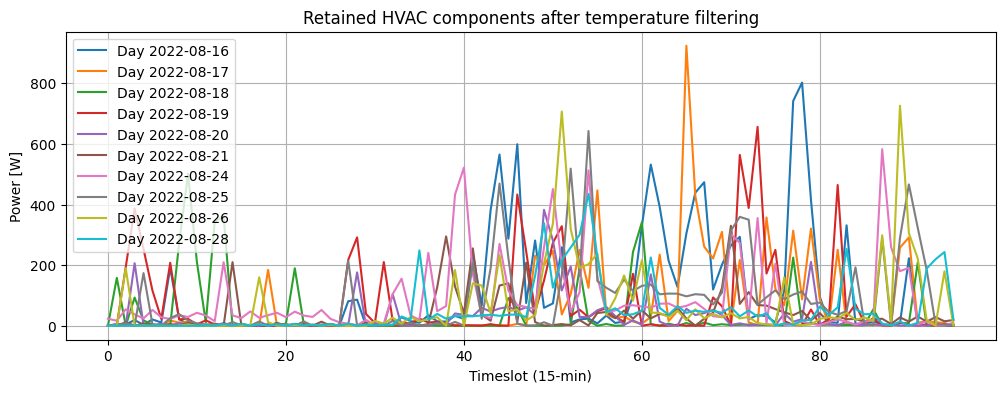

           r_out       r_in
count  66.000000  66.000000
mean   -0.010176  -0.019773
std     0.240461   0.194399
min    -0.456246  -0.375919
25%    -0.206355  -0.163555
50%    -0.128326  -0.074473
75%     0.201447   0.111847
max     0.437258   0.579054


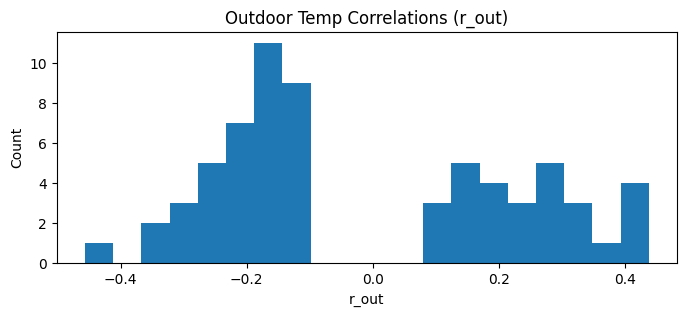

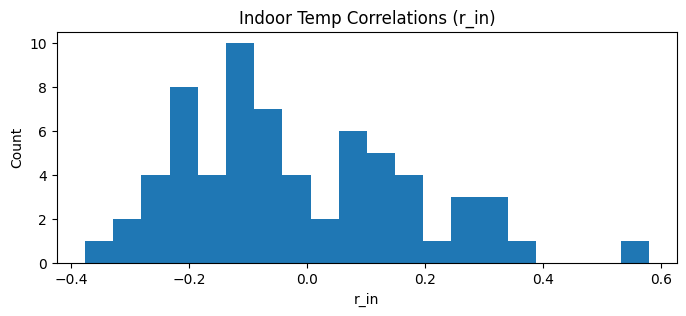

IndexError: list index out of range

In [137]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import FastICA
from sklearn.metrics import f1_score

hvac_comps = []
kept_days  = []

def extract_hvac_component(R, T_day, GT_day=None, n_comp=5, min_corr=0.1, t_low=15, t_high=25):
    if R.shape[1] != 1:
        raise ValueError("R should be (96, 1) after averaging residuals.")

    r_vec = R.flatten()
    T_day = T_day[:len(r_vec)]

    active_mask = (T_day < t_low) | (T_day > t_high)
    if not np.any(active_mask):
        print("⚠️ No active HVAC periods based on temperature.")
        return None

    r_active = r_vec[active_mask]
    T_active = T_day[active_mask]
    GT_active = GT_day[active_mask] if GT_day is not None else None

    if np.std(r_active) == 0:
        print("⚠️ Zero variance in residuals. Skipping.")
        return None

    # ICA needs more samples — instead, treat r_active as single signal
    hvac = r_vec  # Already 96 time points

    corr = np.corrcoef(hvac, T_day)[0, 1]
    if abs(corr) < min_corr:
        print(f"⚠️ Weak corr ({corr:.2f}), skipping.")
        return None

    return hvac
  
def extract_hvac_component_with_gt(R, gt_binary, n_comp=5, min_f1=0.2):
    X = R.T

    if np.std(X) < 1e-3 or np.all(np.std(X, axis=0) < 1e-3):
        print("⚠️ Skipping: Residuals have too little variation.")
        return None

    try:
        ica = FastICA(n_components=n_comp, random_state=42, whiten='unit-variance', max_iter=1000, tol=1e-4)
        S = ica.fit_transform(X)
        A = ica.mixing_
    except Exception as e:
        print(f"⚠️ ICA failed: {e}")
        return None

    best_f1 = 0
    best_signal = None

    for i in range(n_comp):
        a = A[:, i]
        a /= np.linalg.norm(a)
        hvac = R.mean(axis=1) @ a * a

        # Normalize + binarify
        threshold = 0.05 * np.max(hvac)
        pred_binary = (hvac > threshold).astype(int)

        # Evaluate against GT
        f1 = f1_score(gt_binary, pred_binary)
        if f1 > best_f1:
            best_f1 = f1
            best_signal = hvac

    if best_f1 < min_f1:
        print(f"❌ No good component (f1={best_f1:.2f})")
        return None

    print(f"✅ Best component F1: {best_f1:.2f}")
    return best_signal

# R0 = residuals[0]  # This is a 96x132 matrix
# plt.figure(figsize=(10, 4))
# for i in range(10):  # plot the first 10 days
#     plt.plot(R0[:, i], label=f'Day {i}')
# plt.title("Residuals across first 10 days")
# plt.xlabel("Time slot")
# plt.legend()
# plt.grid()
# plt.show()

# for i in range(3):
#     Rj = residuals[i]
#     Rj = np.clip(Rj, 0, None)  # make sure clipping is done
#     plt.figure(figsize=(10, 3))
#     for col in range(Rj.shape[1]):
#         plt.plot(Rj[:, col], alpha=0.3)
#     plt.title(f"Residuals for day index {i}")
#     plt.xlabel("Timeslot")
#     plt.ylabel("Residual Power [W]")
#     plt.grid()
#     plt.show()

df['hvac_binary'] = df['hvac_mode'].isin([1, 2]).astype(int)
for Rj, day in zip(residuals, hvac_days):
    Tj = df['Tout'].loc[day: day + pd.Timedelta(days=1)].values[:96]
    GTj = df['hvac_binary'].loc[day: day + pd.Timedelta(days=1)].values[:96]  # optional
    R_mean = Rj.mean(axis=1)  # shape (96,)
    comp = extract_hvac_component(R_mean.reshape(-1, 1), Tj, GT_day=GTj)
    if comp is not None:
        hvac_comps.append(comp)
        kept_days.append(day)
# for Rj, day in zip(residuals, hvac_days):
#     Tj = df['Tout'].loc[day: day + pd.Timedelta(days=1)].values[:96]
#     comp = extract_hvac_component(Rj, Tj, n_comp=3, min_corr=0.1, t_low=t_low, t_high=t_high)
#     if comp is not None:
#         hvac_comps.append(comp)
#         kept_days .append(day)
    
PHVAC_ica = np.vstack(hvac_comps)     
PHVAC_ica = np.clip(PHVAC_ica, 0, None)

plt.figure(figsize=(12, 4))
for i in range(min(10, len(PHVAC_ica))):
    plt.plot(PHVAC_ica[i], label=f'Day {kept_days[i].strftime("%Y-%m-%d")}')
plt.title("Retained HVAC components after temperature filtering")
plt.xlabel("Timeslot (15-min)")
plt.ylabel("Power [W]")
plt.legend()
plt.grid()
plt.show()

corrs = []
for comp, day in zip(hvac_comps, kept_days):
    T_out = df['Tout'].loc[day: day + pd.Timedelta(days=1)].values[:96]
    T_in  = df['Tin' ].loc[day: day + pd.Timedelta(days=1)].values[:96]
    r_out = np.corrcoef(comp, T_out)[0,1]
    r_in  = np.corrcoef(comp, T_in )[0,1]
    corrs.append({'day': day, 'r_out': r_out, 'r_in': r_in})

df_corr = pd.DataFrame(corrs).set_index('day')
print(df_corr.describe())

# 2) Plot histograms to eyeball elbows
plt.figure(figsize=(8,3))
plt.hist(df_corr['r_out'], bins=20)
plt.title('Outdoor Temp Correlations (r_out)')
plt.xlabel('r_out')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8,3))
plt.hist(df_corr['r_in'], bins=20)
plt.title('Indoor Temp Correlations (r_in)')
plt.xlabel('r_in')
plt.ylabel('Count')
plt.show()

def filter_hvac_by_temp_corr(hvac_comps, days, df, tout_col='Tout', tin_col ='Tin', th=0.3, t_low=15, t_high=25):
    kept_comp, kept_days = [], []
    print(t_low, t_high)
    daily_temp = df[tout_col].resample('D').mean().dropna()
    for comp, day in zip(hvac_comps, days):
        Tout = df[tout_col].loc[day:day+pd.Timedelta(days=1)].values[:96]

        Ph = comp.reshape(24,4).sum(axis=1)
        Th = Tout.reshape(24,4).mean(axis=1)
        r_hourly = np.corrcoef(Ph, Th)[0,1]

        avgT = daily_temp.at[day]

        if avgT > t_high:
            # cooling day
            #  and (r_in <= -th/2)
            if (r_hourly >=  th):
                kept_comp.append(comp)
                kept_days.append(day)
            else:
                print(f"Dropping {day}: cooling(corr_out={r_hourly:.2f}, T_out={avgT:.2f}°C")
        elif avgT < t_low:
            # heating day
            # and (r_in >=  th/2)
            if (r_hourly <= -th):
                kept_comp.append(comp)
                kept_days.append(day)
            else:
                print(f"Dropping {day}: heating(corr_out={r_hourly:.2f}, T_out={avgT:.2f}°C")
        else:
            # mild day — keep by default
            kept_comp.append(comp)
            kept_days.append(day)
            print(f"Keeping mild day {day} (T_out={avgT:.2f}°C)")

    return kept_comp, kept_days


def fine_tune_hvac(comps, days, df, temp_col='Tout', eps=0.1):
    tuned = []
    for comp, day in zip(comps, days):
        # 1) get that day's temp and total load
        T15 = df[temp_col].loc[day: day+pd.Timedelta(days=1)].values[:96]
        P15 = df['total_energy'].loc[day: day+pd.Timedelta(days=1)].values[:96]
        # 2) aggregate to hourly
        Th = np.array([T15[i*4:(i+1)*4].mean() for i in range(24)]).reshape(-1,1)
        Ph = np.array([comp[i*4:(i+1)*4].sum() for i in range(24)])
        # 3) fit quadratic model
        X = np.hstack([Th, Th**2])
        model = LinearRegression().fit(X, Ph)
        g1, g2 = model.coef_
        # 4) compute per-hour preds and ±eps bounds
        pred_h = (g1*Th.flatten() + g2*Th.flatten()**2)
        lb_h   = pred_h - eps
        ub_h   = pred_h + eps
        # 5) clip each 15-min of comp
        comp_tuned = comp.copy()
        for h in range(24):
            lo, hi = lb_h[h]/4, ub_h[h]/4
            idx = slice(4*h, 4*h+4)
            comp_tuned[idx] = np.clip(comp_tuned[idx], lo, hi)
        # 6) enforce 0 ≤ HVAC ≤ total load
        comp_tuned = np.minimum(np.maximum(comp_tuned, 0), P15)
        tuned.append(comp_tuned)
    return np.vstack(tuned)

i = 70  # any index
R = residuals[i]
r_mean = R.mean(axis=1)
T = df['Tout'].loc[kept_days[i]: kept_days[i] + pd.Timedelta(days=1)].values[:96]

plt.figure(figsize=(12,4))
plt.plot(r_mean, label='Mean residual')
plt.plot(T, label='Outdoor Temp', alpha=0.7)
plt.title(f"Residual vs Temp on {kept_days[i].date()}")
plt.legend()
plt.grid()
plt.show()

# PHVAC_final = fine_tune_hvac(
#     hvac_comps,
#     kept_days,
#     df,
#     temp_col='Tout',
#     eps=0.1
# ) 

              precision    recall  f1-score   support

         OFF       0.58      0.57      0.58      3386
          ON       0.52      0.52      0.52      2950

    accuracy                           0.55      6336
   macro avg       0.55      0.55      0.55      6336
weighted avg       0.55      0.55      0.55      6336



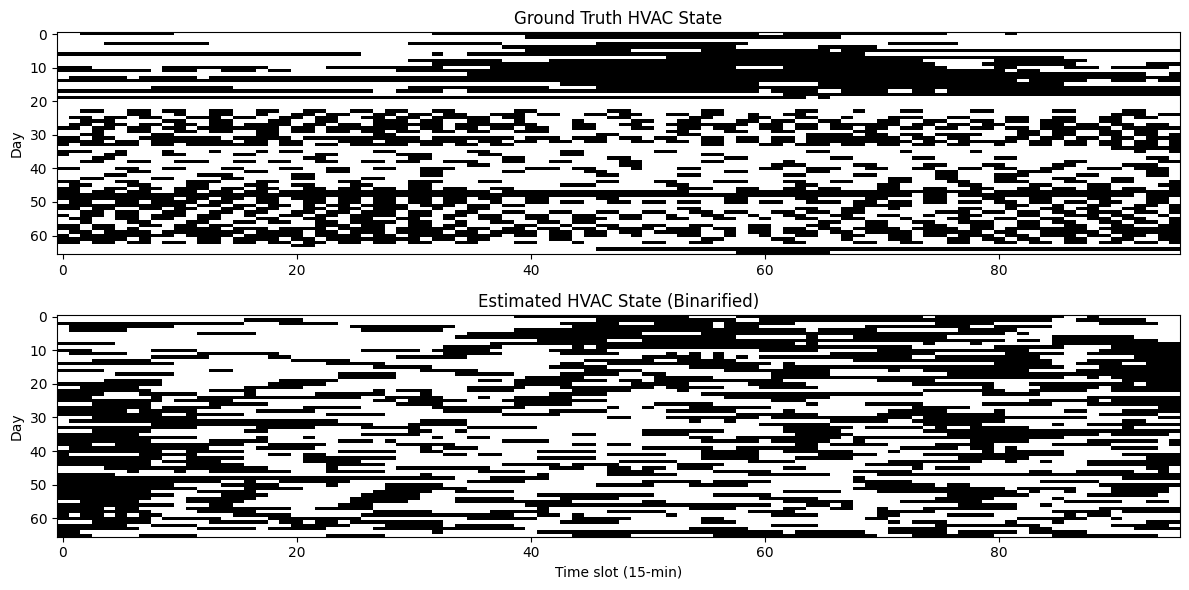

<Figure size 500x400 with 0 Axes>

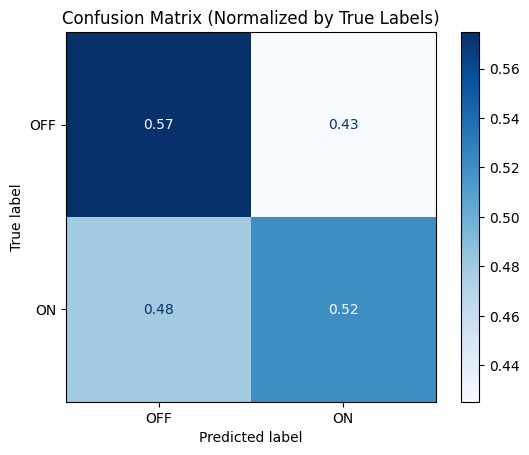

In [141]:
from scipy.ndimage import uniform_filter1d

df['hvac_binary'] = df['hvac_mode'].isin([1, 2]).astype(int)
def build_ground_truth_matrix(df, days, col='hvac_binary'):
    gt_matrix = []
    used_days = []

    for day in days:
        values = df[col].loc[day : day + pd.Timedelta(days=1)].values[:96]
        if len(values) == 96:
            gt_matrix.append(values)
            used_days.append(day)

        else:
            print(f"Skipping {day}, incomplete data")
    return np.vstack(gt_matrix), used_days

GT_binary, GT_binary_days = build_ground_truth_matrix(df, kept_days)

def binarify_components(hvac_matrix, threshold_ratio=50, smooth_window=5):
    binary_matrix = np.zeros_like(hvac_matrix)
    for i, comp in enumerate(hvac_matrix):
        smoothed = uniform_filter1d(comp, size=smooth_window)
        local_thresh = threshold_ratio * np.median(smoothed)
        binary_matrix[i] = (smoothed > local_thresh).astype(int)
    return binary_matrix


PHVAC_binary = binarify_components(PHVAC_ica, threshold_ratio=1.05)
from sklearn.metrics import classification_report

hvac_pred_flat = PHVAC_binary.flatten()
hvac_true_flat = GT_binary.flatten()

print(classification_report(hvac_true_flat, hvac_pred_flat, target_names=["OFF", "ON"]))
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.imshow(GT_binary, aspect='auto', cmap='gray_r')
plt.title("Ground Truth HVAC State")
plt.ylabel("Day")

plt.subplot(2, 1, 2)
plt.imshow(PHVAC_binary, aspect='auto', cmap='gray_r')
plt.title("Estimated HVAC State (Binarified)")
plt.xlabel("Time slot (15-min)")
plt.ylabel("Day")

plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(hvac_true_flat, hvac_pred_flat, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["OFF", "ON"])

plt.figure(figsize=(5, 4))
disp.plot(cmap='Blues', values_format=".2f")
plt.title("Confusion Matrix (Normalized by True Labels)")
plt.show()

In [10]:
hvac_comps_filt, days_filt = filter_hvac_by_temp_corr(
    hvac_comps,
    kept_days,
    df,
    tout_col='Tout',
    tin_col ='Tin',
    th=0.05,
    t_low=t_low,
    t_high=t_high
)
print(f"Kept {len(hvac_comps_filt)} of {len(hvac_comps)} days after seasonal filter")

PHVAC_final = fine_tune_hvac(
    hvac_comps_filt,
    days_filt,
    df,
    temp_col='Tout',
    eps=0.1
) 
print("PHVAC_final shape:", PHVAC_final.shape)

2.4032097222222206 15.871213762626265
Dropping 2022-08-16 00:00:00: cooling(corr_out=0.01, T_out=22.18°C
Dropping 2022-08-22 00:00:00: cooling(corr_out=0.02, T_out=22.34°C
Dropping 2022-09-08 00:00:00: cooling(corr_out=0.04, T_out=21.44°C
Dropping 2022-09-20 00:00:00: cooling(corr_out=0.01, T_out=18.44°C
Dropping 2022-11-14 00:00:00: heating(corr_out=0.40, T_out=1.47°C
Dropping 2022-11-15 00:00:00: heating(corr_out=0.40, T_out=1.76°C
Dropping 2022-11-17 00:00:00: heating(corr_out=0.23, T_out=1.93°C
Dropping 2022-11-18 00:00:00: heating(corr_out=0.45, T_out=0.35°C
Dropping 2022-11-19 00:00:00: heating(corr_out=0.01, T_out=-0.60°C
Dropping 2022-11-20 00:00:00: heating(corr_out=0.75, T_out=-2.66°C
Dropping 2022-11-21 00:00:00: heating(corr_out=0.49, T_out=1.08°C
Dropping 2022-12-01 00:00:00: heating(corr_out=0.19, T_out=0.75°C
Dropping 2022-12-04 00:00:00: heating(corr_out=0.46, T_out=1.57°C
Dropping 2022-12-09 00:00:00: heating(corr_out=0.60, T_out=-0.35°C
Dropping 2022-12-10 00:00:00: h

th_low = 2.1 W, th_high = 39.1 W


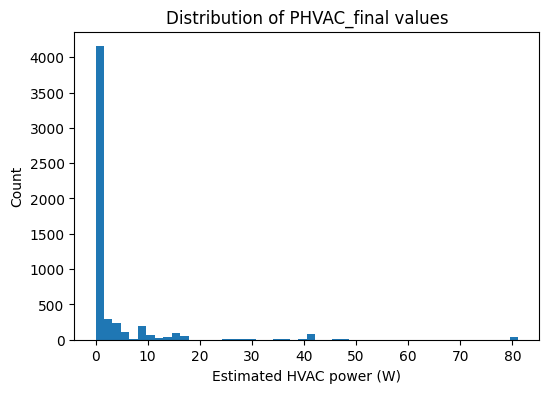

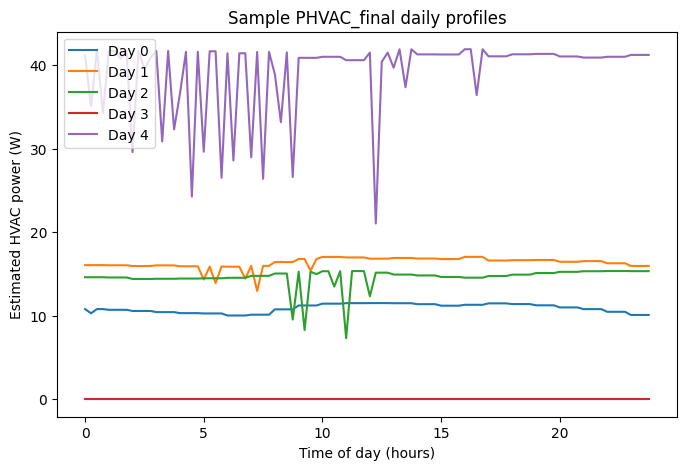

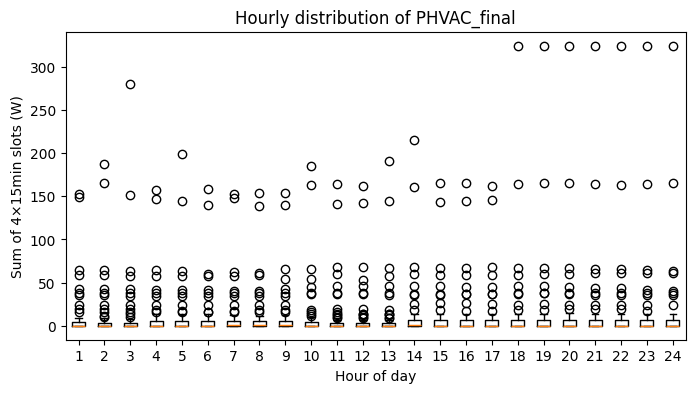

In [92]:
def classify_hvac(PHVAC_final, low_pct=10, high_pct=90, min_nonzero=1.0):
    # flatten to choose thresholds
    flat = PHVAC_final.flatten()
    # throw away zeros and any super-small noise floor
    non_zero = flat[flat >= min_nonzero]
    if len(non_zero)==0:
        raise ValueError("No non-zero values ≥ min_nonzero; lower your floor.")
    
    th_low  = np.percentile(non_zero, low_pct)
    th_high = np.percentile(non_zero, high_pct)
    
    # build 3-level mask
    three_level = np.zeros_like(PHVAC_final, dtype=int)
    three_level[PHVAC_final > th_low ] = 1
    three_level[PHVAC_final > th_high] = 2
    
    # binary on/off
    binary = (PHVAC_final > th_low).astype(int)
    
    return binary, three_level, th_low, th_high

binary_labels, three_lvl_labels, th_low, th_high = classify_hvac(
    PHVAC_final,
    low_pct=10,    # 10th percentile of non-zero values
    high_pct=90,   # 90th percentile of non-zero values
    min_nonzero=1  # ignore any UX <1W as noise
)
print(f"th_low = {th_low:.1f} W, th_high = {th_high:.1f} W")

plt.figure(figsize=(6,4))
plt.hist(PHVAC_final.flatten(), bins=50)
plt.title("Distribution of PHVAC_final values")
plt.xlabel("Estimated HVAC power (W)")
plt.ylabel("Count")
plt.show()

# 2) Kernel density estimate (optional, needs seaborn)
# import seaborn as sns
# sns.kdeplot(PHVAC_final.flatten(), bw_adjust=0.5)
# plt.title("KDE of PHVAC_final")
# plt.show()

# 3) Plot a handful of daily curves
days_to_plot = [0, 1, 2, 3, 4]  # change indices as you like
plt.figure(figsize=(8,5))
for i in days_to_plot:
    plt.plot(np.arange(96)*15/60, PHVAC_final[i], label=f"Day {i}")
plt.title("Sample PHVAC_final daily profiles")
plt.xlabel("Time of day (hours)")
plt.ylabel("Estimated HVAC power (W)")
plt.legend()
plt.show()

# 4) Boxplot by hour of day
# Aggregate into 24 hourly bins
hourly = PHVAC_final.reshape(-1, 24, 4).sum(axis=2)  # shape: (n_days, 24)
plt.figure(figsize=(8,4))
plt.boxplot([hourly[:,h] for h in range(24)])
plt.title("Hourly distribution of PHVAC_final")
plt.xlabel("Hour of day")
plt.ylabel("Sum of 4×15min slots (W)")
plt.show()

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Kelsier\.conda\envs\thesis\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Kelsier\.conda\envs\thesis\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Kelsier\.conda\envs\thesis\Lib\subprocess.py", line 1538, in 

Cluster centers: zero=47.4 W, light=263.7 W, heavy=705.6 W
Off/On threshold = 155.6 W


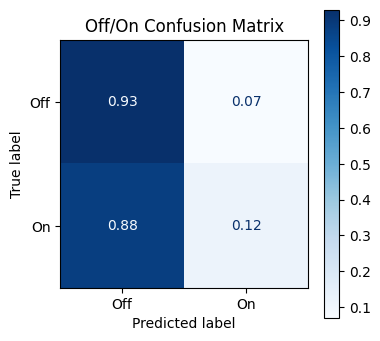

Classification Report (binary Off=0, On=1):
              precision    recall  f1-score   support

         Off       0.60      0.93      0.73      2742
          On       0.55      0.12      0.20      1962

    accuracy                           0.59      4704
   macro avg       0.57      0.52      0.46      4704
weighted avg       0.58      0.59      0.51      4704



In [12]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
flat = PHVAC_final.flatten().reshape(-1,1)

# 2) Fit 3 clusters
km3 = KMeans(n_clusters=3, random_state=0).fit(flat)
centers = sorted(km3.cluster_centers_.flatten())
c0, c1, c2 = centers
print(f"Cluster centers: zero={c0:.1f} W, light={c1:.1f} W, heavy={c2:.1f} W")

# 3) Thresholds
th_off_on = (c0 + c1) / 2        # off vs on
th_on_high = (c1 + c2) / 2       # low vs high, if you ever need it

print(f"Off/On threshold = {th_off_on:.1f} W")

# 4) Build your binary mask
binary_3km = (PHVAC_final > th_off_on).astype(int)

# 5) Smooth isolated flips
for day in range(binary_3km.shape[0]):
    seq = binary_3km[day]
    for i in range(1,95):
        if seq[i-1]==0 and seq[i]==1 and seq[i+1]==0:
            seq[i] = 0
# flat = PHVAC_final.flatten()
# noise_floor = 5 
# on_vals = flat[flat > noise_floor].reshape(-1,1)

# km = KMeans(n_clusters=2, random_state=0).fit(on_vals)
# c1, c2 = sorted(km.cluster_centers_.flatten())

# th_unsup = float((c1 + c2) / 2)
# print(f"Unsupervised on/off threshold = {th_unsup:.1f} W")

binary_unsup = (PHVAC_final > th_off_on).astype(int)

# for day in range(binary_unsup.shape[0]):
#     seq = binary_unsup[day]
#     for i in range(1,95):
#         if seq[i-1]==0 and seq[i]==1 and seq[i+1]==0:
#             seq[i] = 0
y_true, y_pred = [], []
for di, day in enumerate(days_filt):
    for slot in range(96):
        ts = day + pd.Timedelta(minutes=15*slot)
        if ts in df.index:
            y_true.append(1 if df.at[ts, 'hvac_mode'] > 0 else 0)
            y_pred.append(binary_unsup[di, slot])

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred, labels=[0,1], normalize='true')
disp = ConfusionMatrixDisplay(cm, display_labels=['Off','On'])
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title("Off/On Confusion Matrix")
plt.show()

print("Classification Report (binary Off=0, On=1):")
print(classification_report(y_true, y_pred, target_names=['Off','On']))

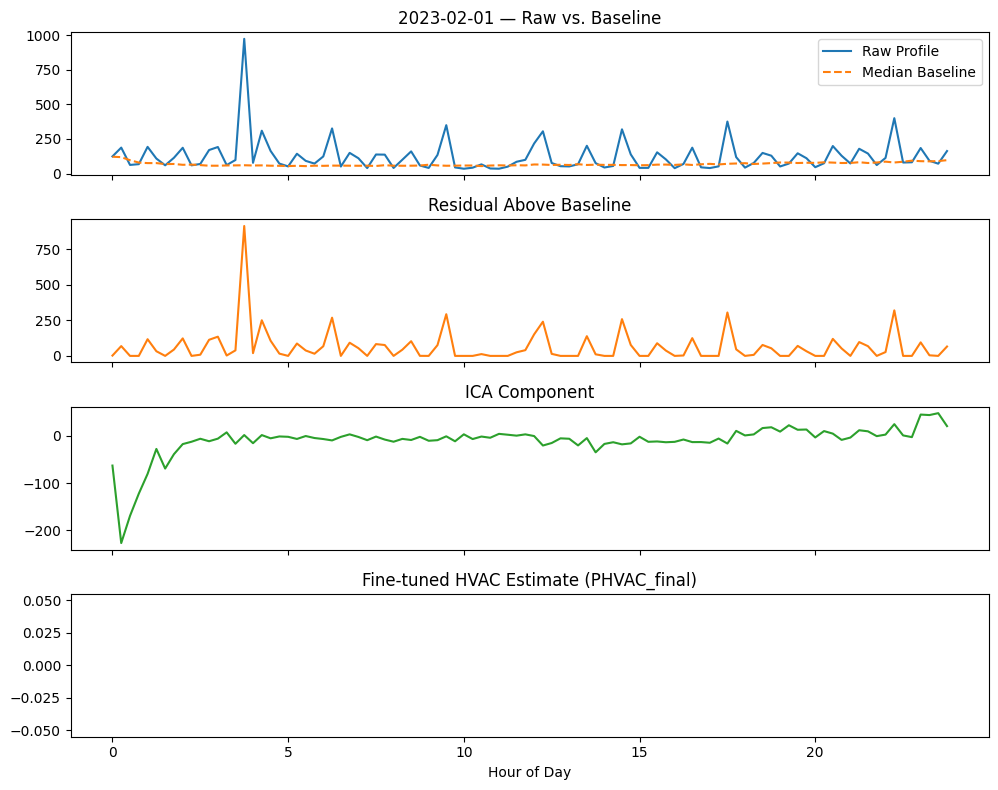

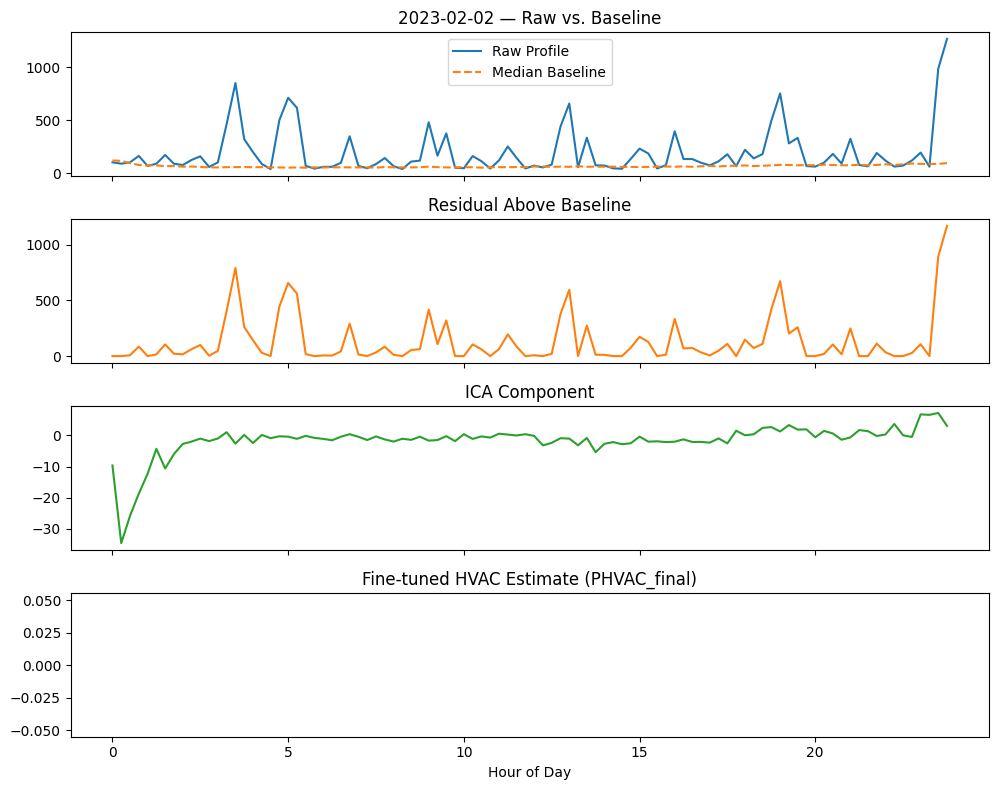

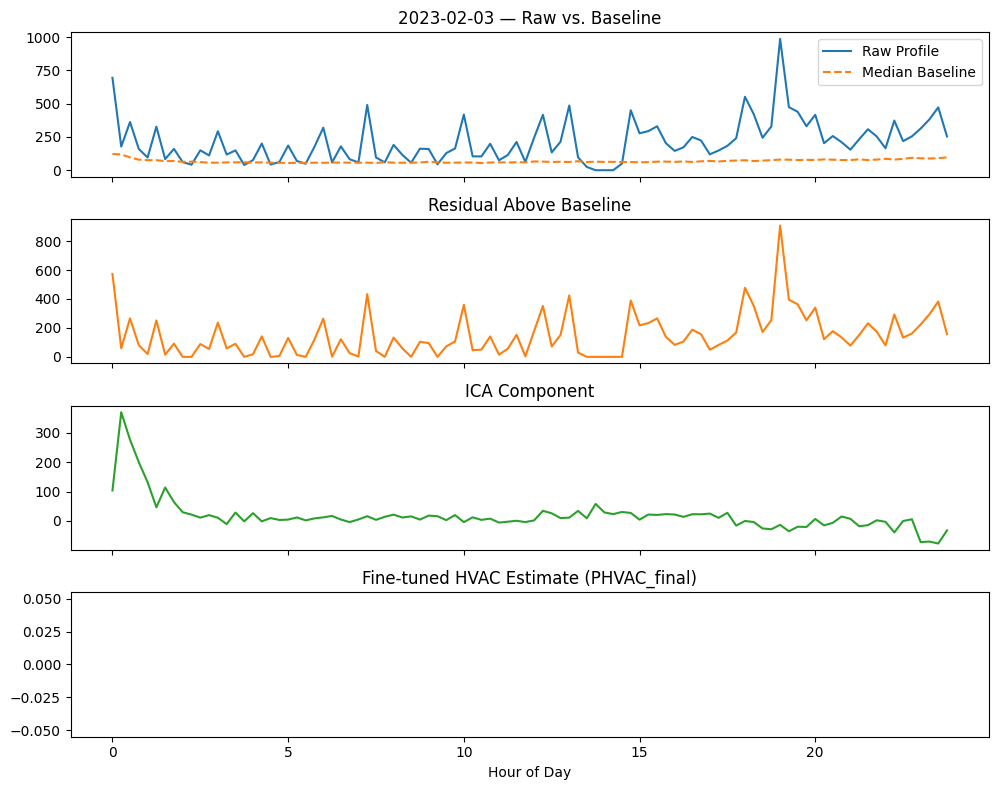

In [11]:
def inspect_days_pipeline(days_to_inspect,
                          df,
                          daily_profiles,
                          kept_days,
                          days_filt,
                          hvac_comps,
                          PHVAC_final):
    """
    For each calendar day in days_to_inspect, plots:
      1) raw daily profile vs. median baseline
      2) residual above baseline
      3) ICA component
      4) fine-tuned PHVAC_final estimate
    """
    # compute the slot-wise median baseline once
    baseline = daily_profiles.median(axis=0).values

    for day in days_to_inspect:
        # locate the indices in each list (if the day survived that stage)
        ica_idx  = kept_days.index(day)    if day in kept_days  else None
        corr_idx = days_filt.index(day)    if day in days_filt  else None

        # extract vectors
        raw_prof = daily_profiles.loc[day].values
        resid    = (raw_prof - baseline).clip(min=0)
        ica_comp = hvac_comps[ica_idx]     if ica_idx  is not None else np.full(96, np.nan)
        phvac    = PHVAC_final[corr_idx]   if corr_idx is not None else np.full(96, np.nan)

        # time axis in hours
        t = np.arange(96) / 4.0

        # build the 4-panel figure
        fig, axes = plt.subplots(4,1,figsize=(10,8), sharex=True)
        axes[0].plot(t, raw_prof, label='Raw Profile')
        axes[0].plot(t, baseline, linestyle='--', label='Median Baseline')
        axes[0].legend()
        axes[0].set_title(f"{day.date()} — Raw vs. Baseline")

        axes[1].plot(t, resid, color='C1')
        axes[1].set_title("Residual Above Baseline")

        axes[2].plot(t, ica_comp, color='C2')
        axes[2].set_title("ICA Component")

        axes[3].plot(t, phvac, color='C3')
        axes[3].set_title("Fine-tuned HVAC Estimate (PHVAC_final)")
        axes[3].set_xlabel("Hour of Day")

        plt.tight_layout()
        plt.show()

feb_days = [d for d in kept_days if d.year==2023 and d.month==2][:3]
inspect_days_pipeline(
    feb_days,
    df,
    daily_profiles,
    kept_days,
    days_filt,
    hvac_comps,
    PHVAC_final,
)

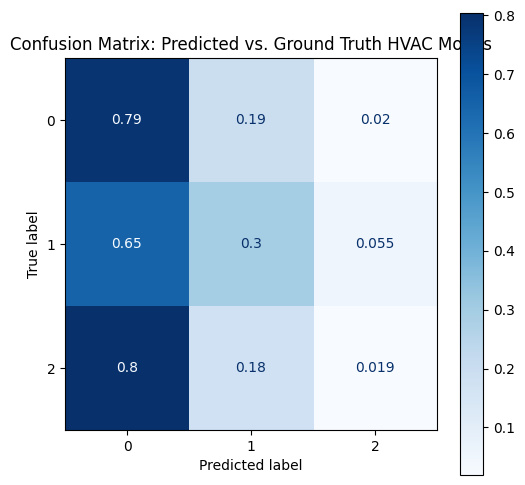

Classification Report:

              precision    recall  f1-score   support

     Off (0)       0.60      0.79      0.68      3226
     Low (1)       0.25      0.30      0.27       944
    High (2)       0.18      0.02      0.03      1302

    accuracy                           0.52      5472
   macro avg       0.34      0.37      0.33      5472
weighted avg       0.44      0.52      0.46      5472



In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_true, y_pred, timestamps = [], [], []
for i, day in enumerate(days_filt):
    for slot in range(96):
        ts = day + pd.Timedelta(minutes=15 * slot)
        if ts in df.index:
            y_true.append(df['hvac_mode'].at[ts])
            y_pred.append(three_lvl_labels[i, slot])
            timestamps.append(ts)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix and classification report
labels = [0, 1, 2]
cm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')
report = classification_report(y_true, y_pred, labels=labels, target_names=['Off (0)', 'Low (1)', 'High (2)'])

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Predicted vs. Ground Truth HVAC Modes')
plt.show()

# Print classification report
print("Classification Report:\n")
print(report)


In [639]:
from sklearn.decomposition import FastICA
from scipy.optimize import minimize
from datetime import timedelta
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
from sklearn.decomposition import PCA

df['date'] = df.index.date
daily_avg_temp = df.groupby('date')['Tout'].mean()
t_low, t_high = 0, 0

def cluster_days_with_pca(df_features, n_clusters=3, n_components=2, plot=True):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_features)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X_scaled)

    df_features['cluster'] = kmeans.labels_

    # if plot:
    #     import matplotlib.pyplot as plt
    #     plt.figure(figsize=(8, 5))
    #     for c in range(n_clusters):
    #         plt.scatter(X_pca[df_features['cluster'] == c, 0], X_pca[df_features['cluster'] == c, 1], label=f'Cluster {c}', alpha=0.6)
    #     plt.xlabel("PCA 1")
    #     plt.ylabel("PCA 2")
    #     plt.title("PCA Projection of Clustering")
    #     plt.legend()
    #     plt.grid(True)
    #     plt.tight_layout()
    #     plt.show()

    return df_features

def add_residual_energy_feature(df_features):
    X = df_features[['Tout_mean']].values
    y = df_features['Energy_mean'].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    # Add absolute residual
    df_features['Energy_residual'] = np.abs(y - y_pred)

    return df_features

def extract_daily_features(df):
    df_daily = df.resample('D').agg({
        'Tout': ['mean', 'std'],
        # 'Tin': ['mean', 'std'],
        'total_energy': 'mean'
    }).dropna()
    
    df_daily.columns = ['Tout_mean', 'Tout_std', 'Energy_mean']
    df_daily = add_residual_energy_feature(df_daily)

    df_daily['weekday'] = df_daily.index.dayofweek

    return df_daily

def extract_day_profiles(df, days):
    profiles = []
    for day in days:
        day_data = df[df.index.normalize() == day]['total_energy']
        if len(day_data) == 96:
            profiles.append(day_data.values)
        else:
            print(f"⚠️ Skipping {day} — only {len(day_data)} samples")
    for i, p in enumerate(profiles):
        if p.shape[0] != 96:
            raise ValueError(f"❌ Profile at index {i} has length {p.shape[0]} — expected 96")
    return np.stack(profiles).T 


def plot_day_classification(df, mild_days_stat, mild_days_true, update=True):
    all_days = pd.date_range(df.index.min().normalize(), df.index.max().normalize(), freq='D')

    # Create binary series for statistical and true mild classifications
    stat_series = pd.Series(0, index=all_days)
    truth_series = pd.Series(0, index=all_days)
    stat_series.loc[mild_days_stat] = 1
    truth_series.loc[mild_days_true] = 1

    plt.figure(figsize=(14, 5))
    plt.plot(stat_series, drawstyle='steps-post', label='Statistical Mild Day (1)', alpha=0.8)
    plt.plot(truth_series, drawstyle='steps-post', label='True Mild Day (1)', alpha=0.6)
    plt.title("Mild Day Classification: Statistical vs Ground Truth (hvac_mode == 0 all day)")
    plt.ylabel("Day Type")
    plt.xlabel("Date")
    plt.yticks([0, 1], ["HVAC", "Mild"])
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    overlap = mild_days_stat.intersection(mild_days_true)
    true_mild_temps = daily_avg_temp[list(overlap)]

    if update:
        t_low, t_high = np.percentile(true_mild_temps, [10, 90])
        print(f"95% range of true mild day temps: {t_low:.1f}°C to {t_high:.1f}°C")

    
    print(f"\n📊 Mild Day Classification Evaluation:")
    print(f"- Total days: {len(all_days)}")
    print(f"- Statistically classified mild days: {len(mild_days_stat)}")
    print(f"- True mild days (hvac_mode == 0): {len(mild_days_true)}")
    print(f"- Overlapping days: {len(overlap)} ({100 * len(overlap) / len(mild_days_true):.1f}% of true mild days)")

def get_true_mild_days(df):
    df_check = df.copy()
    df_check['date'] = df_check.index.normalize()
    grouped = df_check.groupby('date')['hvac_mode']
    mild_true_days = grouped.filter(lambda x: (x == 0).all()).index.normalize().unique()
    return pd.DatetimeIndex(mild_true_days)

def find_mild_cluster(df_features):
    cluster_stats = df_features.groupby('cluster').mean()
    mild_cluster = cluster_stats['Energy_mean'].idxmin()
    mild_days = df_daily[df_daily['cluster'] == mild_cluster].index
    hvac_days = df_daily[df_daily['cluster'] != mild_cluster].index
    return mild_days, hvac_days


df_daily = extract_daily_features(df)

df_clustered = cluster_days_with_pca(df_daily)

# mild_days_stat, hvac_days = find_mild_cluster(df_clustered)
# mild_days_true = get_true_mild_days(df)
# overlap = mild_days_stat.intersection(mild_days_true)

# true_mild_temps = daily_avg_temp[list(overlap)]
# t_low, t_high = np.percentile(true_mild_temps, [5, 95])

# print(f"95% of true mild day temps lie between {t_low:.1f}°C and {t_high:.1f}°C")
# mild_days_filtered = [
#     day for day in mild_days_stat
#     if t_low <= daily_avg_temp.get(day.date(), 0) <= t_high
# ]
# hvac_days_filtered = [day for day in hvac_days if day not in mild_days_filtered]
# print(f"Filtered mild days: {len(mild_days_filtered)}")
# plot_day_classification(df, pd.DatetimeIndex(mild_days_filtered), mild_days_true, update=False)
mild_days = get_true_mild_days(df)
hvac_days = df_daily.index.difference(mild_days)

P_hvac = extract_day_profiles(df, hvac_days)
P_mild = extract_day_profiles(df, mild_days)

assert isinstance(P_hvac, np.ndarray)
assert P_hvac.shape == (96, P_hvac.shape[1])
assert P_hvac.dtype != 'object'


def compute_residuals(P_hvac, P_mild):
    assert P_hvac.shape[0] == 96, f"P_hot has {P_hvac.shape[0]} rows"
    assert P_mild.shape[0] == 96, f"P_mild has {P_mild.shape[0]} rows"
    K = P_mild.shape[1]
    M = P_hvac.shape[1]
    residuals = []
    for j in range(M):
        residual_j = np.stack([P_hvac[:, j] - P_mild[:, k] for k in range(K)], axis=1)  
        assert residual_j.shape == (96, K), f"residual_j shape wrong: {residual_j.shape}"
        residuals.append(residual_j)
    return residuals 

Pres_list = compute_residuals(P_hvac, P_mild)

def apply_ica(residuals, valid_days):
   
    ica_results = []
    kept_days = []

    for i, Pres in enumerate(residuals):
        ica = FastICA(n_components=2, max_iter=1000)
        components = ica.fit_transform(Pres).T  # shape (2, 96)
        assert components.shape[1] == 96
        hvac = components[np.argmax(components.std(axis=1))]
        ica_results.append(hvac)
        kept_days.append(valid_days[i])

    return np.array(ica_results), kept_days  

def filter_ica_by_temp_correlation(PHVAC_ica, kept_days, df, min_corr=0.3):
    good_signals = []
    good_days = []

    for i, day in enumerate(kept_days):
        Tout = df.loc[day:day + timedelta(days=1), 'Tout'].values[:96]
        hvac = PHVAC_ica[i]

        if len(Tout) == 96 and len(hvac) == 96:
            corr = np.corrcoef(hvac, -Tout)[0, 1] 
            if np.abs(corr) > min_corr:
                good_signals.append(hvac)
                good_days.append(day)

    return np.array(good_signals), good_days


PHVAC_ica, kept_hvac_days = apply_ica(Pres_list, hvac_days)
PHVAC_ica_filtered, kept_hvac_days = filter_ica_by_temp_correlation(PHVAC_ica, kept_hvac_days, df)


def fine_tune_hvac(hvac_init, total_load, Tout):
    T = Tout[:96]
    T_hourly = T.reshape(24, 4).mean(axis=1)  # (24,)

    best_loss = float('inf')
    best_hvac = hvac_init.copy()

    for w in [0.7, 0.65, 0.6, 0.55, 0.5]:  # Sweep different weightings
        def loss_fn(params):
            alpha, gamma1, gamma2 = params
            hvac_scaled = alpha * hvac_init
            hourly_avg = hvac_scaled.reshape(24, 4).mean(axis=1)
            hourly_bound = gamma1 * T_hourly + gamma2 * T_hourly**2

            recon_error = np.mean((total_load[:96] - hvac_scaled) ** 2)
            hvac_penalty = np.mean((hourly_avg - hourly_bound) ** 2)

            return w * recon_error + (1 - w) * hvac_penalty

        x0 = [1.0, 0.1, 0.001]
        res = minimize(loss_fn, x0, method='L-BFGS-B')

        if res.success:
            loss_val = loss_fn(res.x)
            if loss_val < best_loss:
                best_loss = loss_val
                best_hvac = res.x[0] * hvac_init  # Save best result

    return best_hvac


PHVAC_final = []
for i, hvac_init in enumerate(PHVAC_ica_filtered):
    # hvac_init = np.clip(hvac_init, 0, np.percentile(hvac_init, 95))

    day = kept_hvac_days[i]
    Tout_day = df.loc[day:day + timedelta(days=1), 'Tout'].values
    total_day = P_hvac[:, hvac_days.get_loc(day)] if day in hvac_days else None
    if total_day is None or len(hvac_init) != 96 or len(Tout_day) < 96 or len(total_day) != 96:
        continue
    PHVAC_final.append(fine_tune_hvac(hvac_init, total_day, Tout_day))

PHVAC_final = np.clip(np.array(PHVAC_final), 0, None)

hvac_profiles = {day: PHVAC_final[i] for i, day in enumerate(kept_hvac_days)}

⚠️ Skipping 2022-08-14 00:00:00 — only 42 samples
⚠️ Skipping 2023-05-09 00:00:00 — only 78 samples


In [642]:
from scipy.ndimage import uniform_filter1d

def binarize_hvac_signal(hvac_signal):
    # percentile_99 = np.percentile(hvac_signal, 95)
    # hvac_signal = np.clip(hvac_signal, 0, percentile_99)
    # hvac_signal = np.where(hvac_signal < 10, 0, hvac_signal)

    smoothed = uniform_filter1d(hvac_signal, size=9)
    logged = np.log1p(smoothed)
    clipped = np.clip(logged, 0, np.percentile(logged, 80))
    norm = (logged - logged.min()) / (logged.max() - logged.min() + 1e-8)
    
    t1 = 0.2  # or np.median(norm) * X
    t2 = 0.6  # or np.percentile(norm, 85)

    bins = np.zeros_like(norm)
    bins[norm > t1] = 1
    bins[norm > t2] = 2
    return bins


PHVAC_class = [binarize_hvac_signal(row) for row in PHVAC_final]
PHVAC_binary = [(row > 0).astype(int) for row in PHVAC_class]


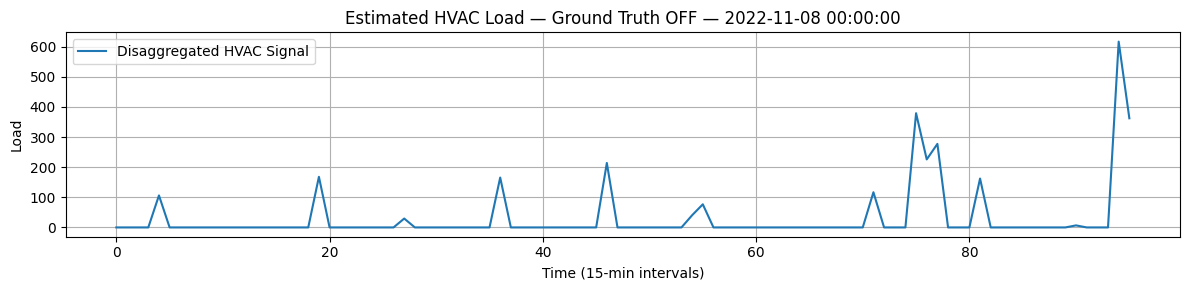

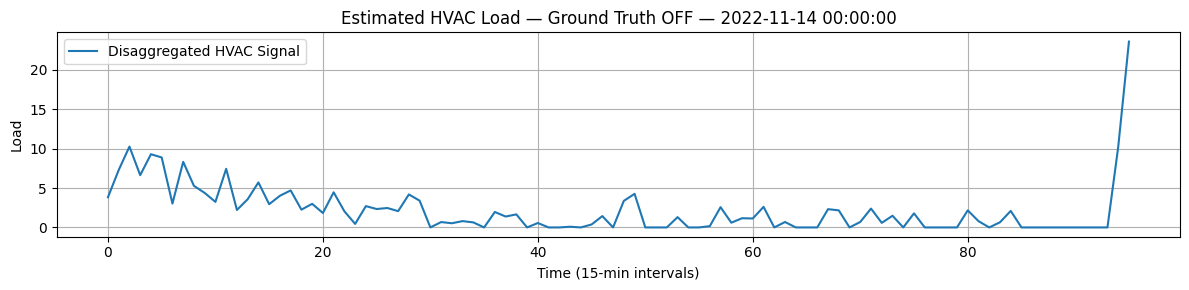

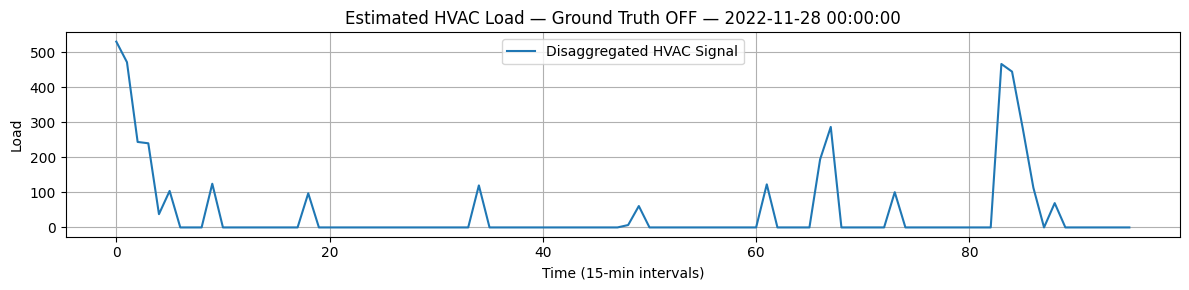

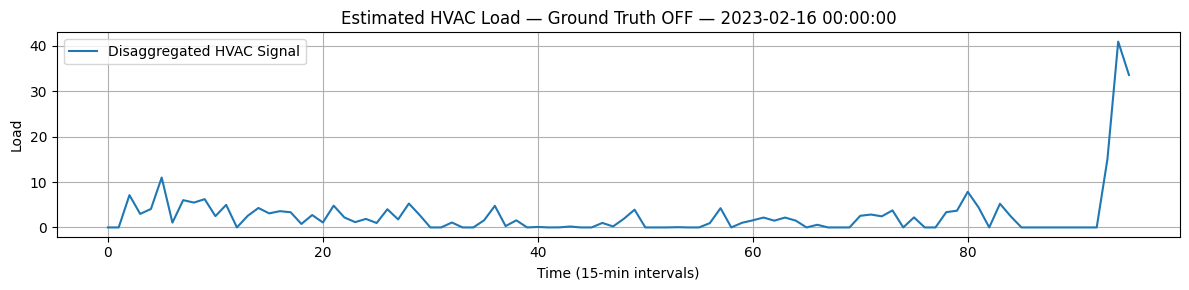

In [382]:
def plot_off_days(PHVAC_final, kept_hvac_days, df, max_plots=5):
    plotted = 0
    for i, day in enumerate(kept_hvac_days):
        # Get true HVAC mode for the full day
        start = pd.Timestamp(day).replace(hour=0, minute=0)
        end = start + pd.Timedelta(minutes=15 * 95)
        hvac_modes = df.loc[start:end, 'hvac_mode'].values

        if len(hvac_modes) == 96 and (hvac_modes == 0).all():
            plt.figure(figsize=(12, 3))
            plt.plot(PHVAC_final[i], label='Disaggregated HVAC Signal')
            plt.title(f"Estimated HVAC Load — Ground Truth OFF — {day}")
            plt.xlabel("Time (15-min intervals)")
            plt.ylabel("Load")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

            plotted += 1
            if plotted >= max_plots:
                break

plot_off_days(PHVAC_final, kept_hvac_days, df)

Multi-class Classification Report:
              precision    recall  f1-score   support

           0      0.540     0.316     0.399      1306
           1      0.210     0.547     0.304       466
           2      0.311     0.222     0.259       724

    accuracy                          0.332      2496
   macro avg      0.354     0.362     0.321      2496
weighted avg      0.412     0.332     0.341      2496



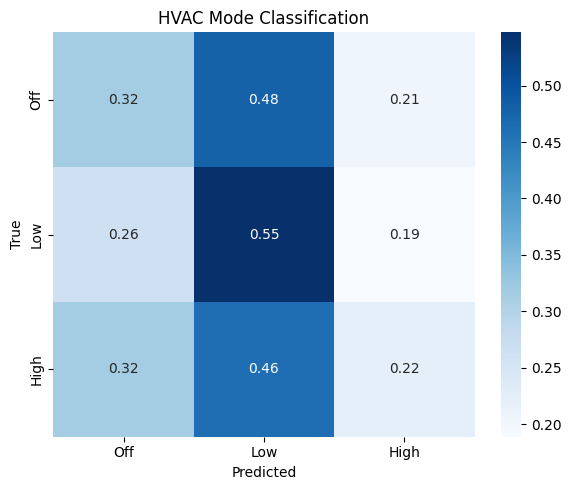


Binary Classification Report:
              precision    recall  f1-score   support

           0      0.540     0.316     0.399      1306
           1      0.484     0.704     0.574      1190

    accuracy                          0.501      2496
   macro avg      0.512     0.510     0.486      2496
weighted avg      0.513     0.501     0.482      2496



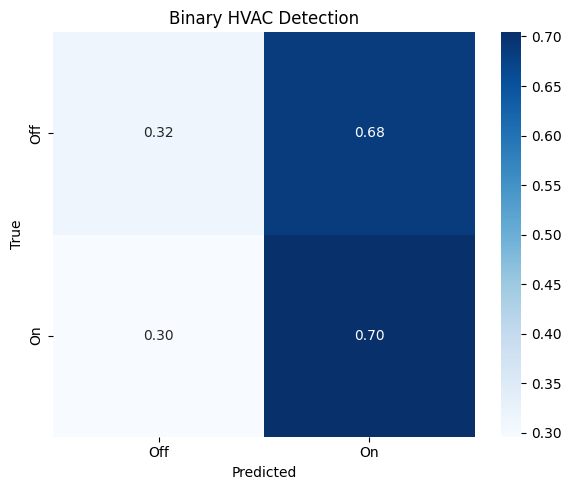

In [643]:
from sklearn.metrics import classification_report, confusion_matrix

def collect_prediction_groundtruth(predictions, days, df, binary=False):
    y_true, y_pred = [], []
    for i, day in enumerate(days):
        start = pd.Timestamp(day).replace(hour=0, minute=0)
        end = start + pd.Timedelta(minutes=15 * 95)
        true_vals = df.loc[start:end, 'hvac_mode'].values
        pred_vals = predictions[i]
        if len(true_vals) != 96 or len(pred_vals) != 96:
            continue
        if binary:
            true_vals = (true_vals > 0).astype(int)
            pred_vals = (pred_vals > 0).astype(int)
        y_true.extend(true_vals)
        y_pred.extend(pred_vals)
    return np.array(y_true), np.array(y_pred)

y_true, y_pred = collect_prediction_groundtruth(PHVAC_class, kept_hvac_days, df)
y_true_bin, y_pred_bin = collect_prediction_groundtruth(PHVAC_binary, kept_hvac_days, df, binary=True)

def plot_confusion(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

print("Multi-class Classification Report:")
print(classification_report(y_true, y_pred, digits=3))
plot_confusion(y_true, y_pred, ['Off', 'Low', 'High'], "HVAC Mode Classification")

print("\nBinary Classification Report:")
print(classification_report(y_true_bin, y_pred_bin, digits=3))
plot_confusion(y_true_bin, y_pred_bin, ['Off', 'On'], "Binary HVAC Detection")

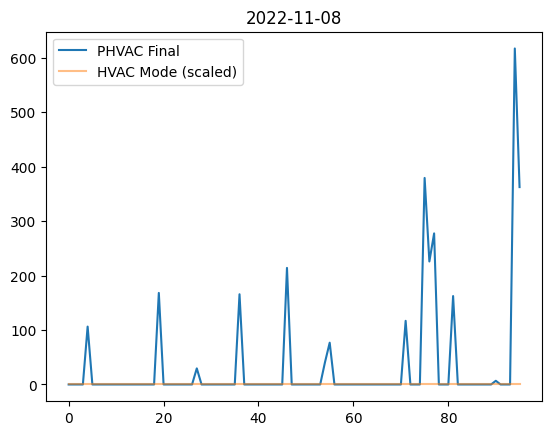

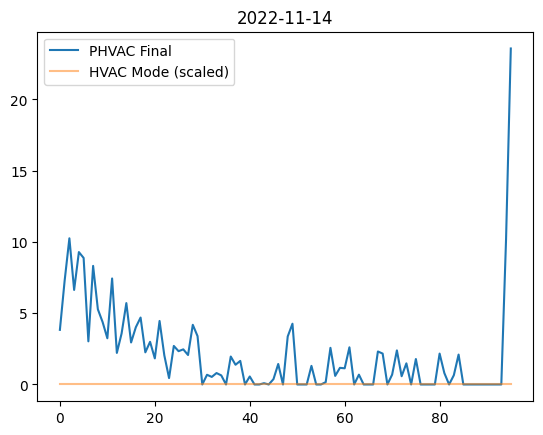

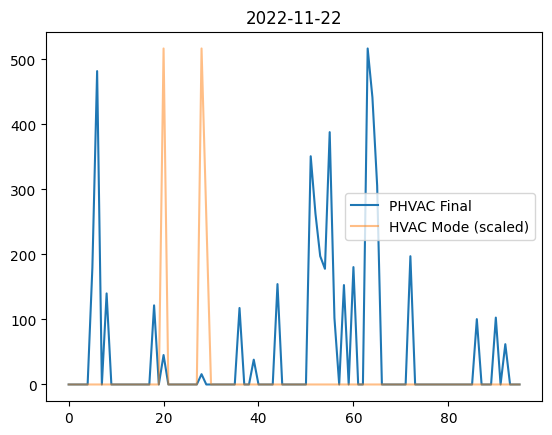

In [385]:
for i in range(3):
    day = kept_hvac_days[i]
    true = df.loc[day:day + timedelta(days=1), 'hvac_mode'].values[:96]
    signal = PHVAC_final[i]

    plt.plot(signal, label='PHVAC Final')
    plt.plot(true * signal.max() / 2, label='HVAC Mode (scaled)', alpha=0.5)
    plt.title(f"{day.date()}")
    plt.legend()
    plt.show()

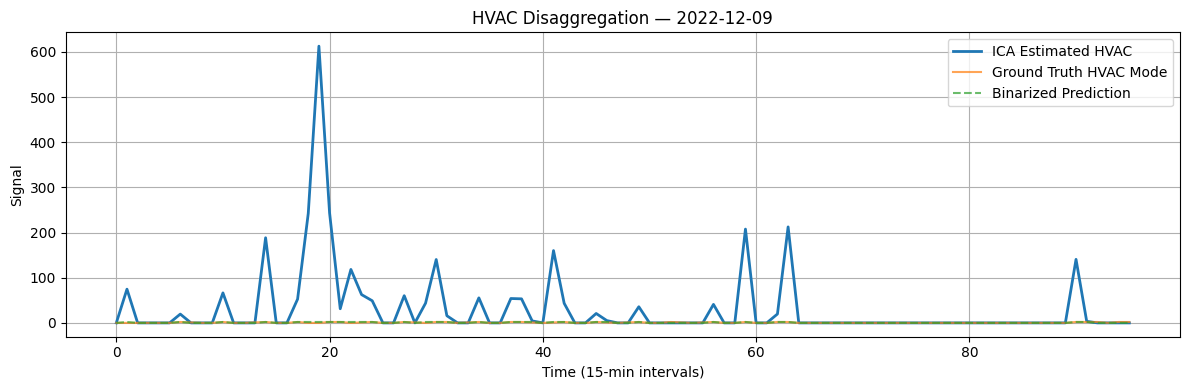

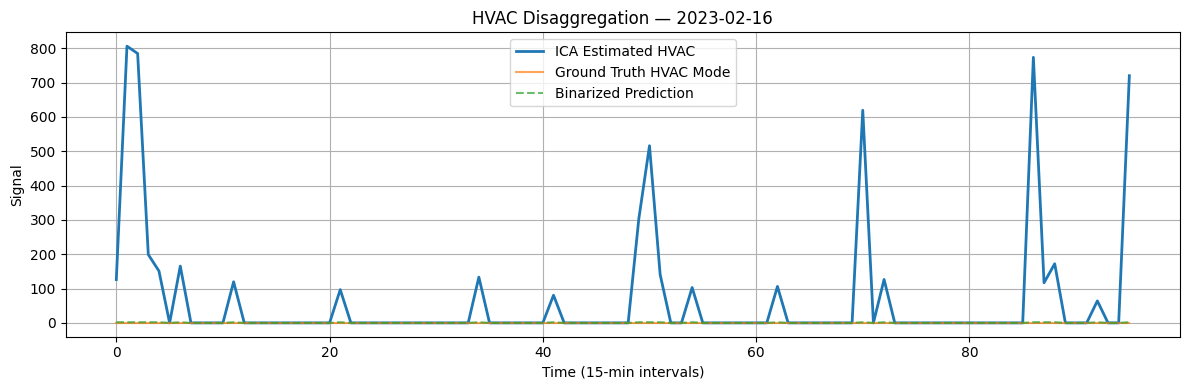

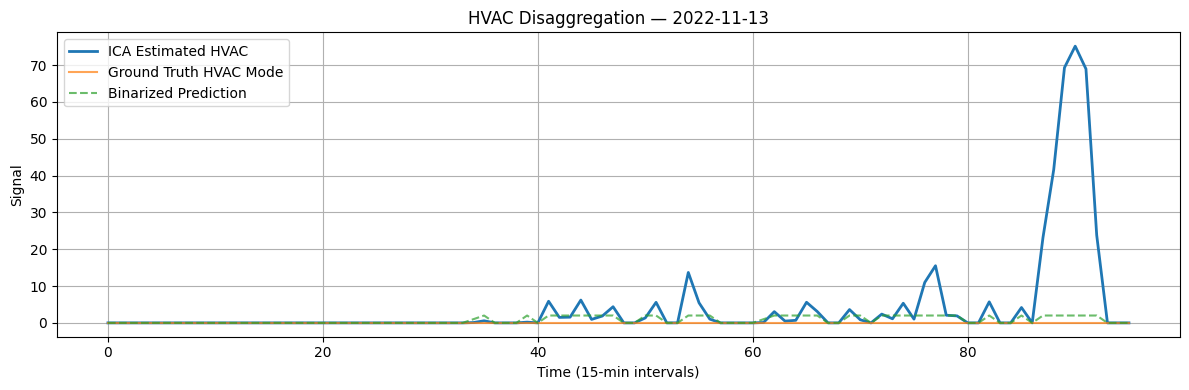

In [149]:
def plot_ica_vs_ground_truth(day, hvac_est, df, show_binary=False, thresholds=None):

    start = pd.to_datetime(day)
    end = start + pd.Timedelta(hours=24)

    ground_truth = df.loc[start:end, 'hvac_mode'].values[:96]
    plt.figure(figsize=(12, 4))
    plt.plot(hvac_est, label="ICA Estimated HVAC", linewidth=2)
    plt.plot(ground_truth, label="Ground Truth HVAC Mode", alpha=0.7)
    
    if show_binary and thresholds:
        low_th, high_th = thresholds
        binary = np.where(hvac_est < low_th, 0,
                 np.where(hvac_est < high_th, 1, 2))
        plt.plot(binary, '--', label="Binarized Prediction", alpha=0.7)

    plt.title(f"HVAC Disaggregation — {day.date()}")
    plt.xlabel("Time (15-min intervals)")
    plt.ylabel("Signal")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


import random

sample_days = random.sample(list(hvac_profiles.keys()), 3)

for day in sample_days:
    plot_ica_vs_ground_truth(day, hvac_profiles[day], df, show_binary=True, thresholds=(0.05, 0.15))

SUPERVISED APPROACH BELOW 

✅ Final Stats:
Train mode distribution: hvac_energy
0    13844
2     4761
1      909
Name: count, dtype: int64
Test mode distribution: hvac_energy
0    3815
2    1497
1      64
Name: count, dtype: int64
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000645 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8747
[LightGBM] [Info] Number of data points in the train set: 5663, number of used features: 36
[LightGBM] [Info] Start training from score 55.416292


c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


🔍 Final HVAC Mode Prediction Performance:
              precision    recall  f1-score   support

     OFF (0)       0.84      0.77      0.80      3815
     LOW (1)       0.34      0.42      0.37       777
    HIGH (2)       0.39      0.48      0.43       777

    accuracy                           0.67      5369
   macro avg       0.52      0.55      0.53      5369
weighted avg       0.70      0.67      0.69      5369



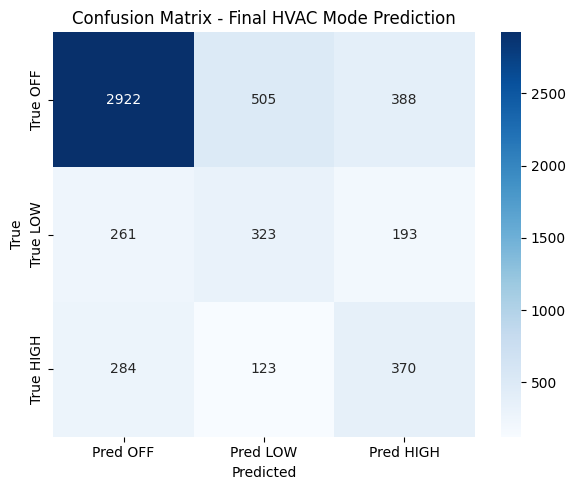

📈 Hybrid Regression Metrics
R²   : 0.13146243301717286
RMSE : 40.584548772018486
MAE  : 21.77810624849837


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22084\1222977602.py:226: UserWarning: Glyph 129482 (\N{ICE CUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129482 (\N{ICE CUBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


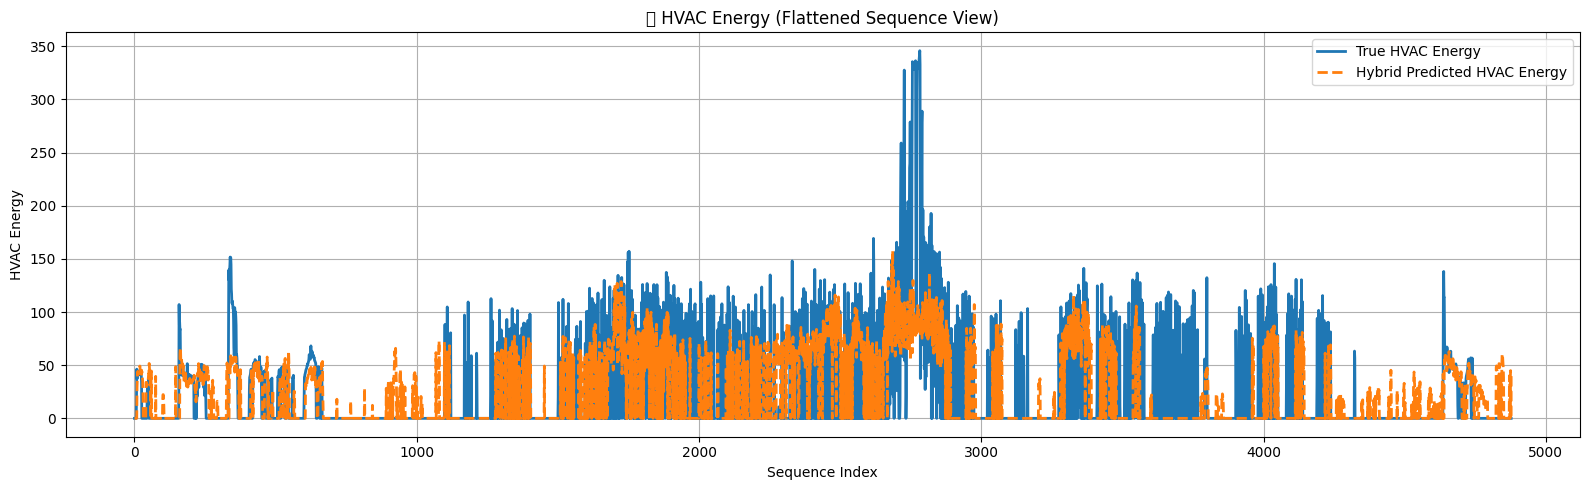

🔍 HVAC ON/OFF Classifier Performance:
              precision    recall  f1-score   support

     OFF (0)       0.87      0.79      0.83      3815
      ON (1)       0.58      0.72      0.64      1554

    accuracy                           0.77      5369
   macro avg       0.73      0.75      0.74      5369
weighted avg       0.79      0.77      0.78      5369



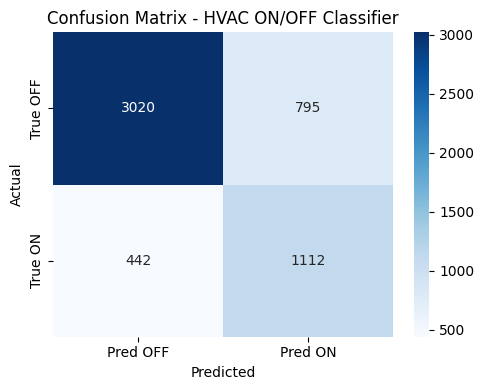

5369 5369 5369
is_on
0    0.709439
1    0.290561
Name: proportion, dtype: float64
is_on
0    0.709635
1    0.290365
Name: proportion, dtype: float64
count    1554.000000
mean       73.537752
std        52.069131
min        10.002380
25%        40.383247
50%        58.583073
75%        98.106838
max       345.726727
Name: hvac_energy, dtype: float64
count    1902.000000
mean       59.236874
std        23.553927
min         6.937407
25%        41.966004
50%        59.137947
75%        74.437802
max       157.971514
Name: hvac_energy_pred, dtype: float64


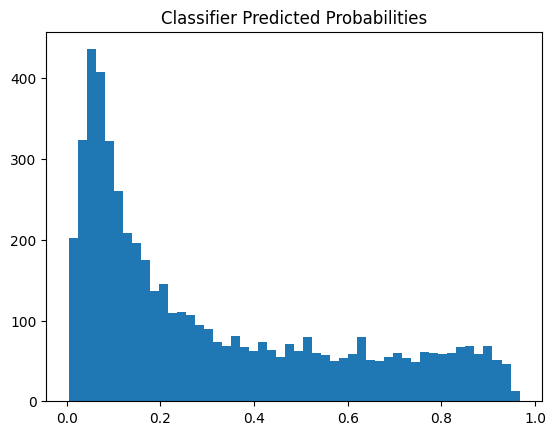

In [22]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor, XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, classification_report, confusion_matrix
import random
from lightgbm import LGBMRegressor


df = dfs[0].copy()
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
df['Tin_rolling'] = df['Tin'].rolling(window=4, min_periods=1).mean()
df['Tout_rolling'] = df['Tout'].rolling(window=4, min_periods=1).mean()
df['total_energy_rolling'] = df['total_energy'].rolling(window=4).mean()
df['total_energy_diff'] = df['total_energy'].diff().bfill()
df['Tin_roll4'] = df['Tin'].rolling(window=4, min_periods=1).mean()
df['Tin_diff'] = df['Tin'] - df['Tin_roll4']
df['total_energy_max'] = df['total_energy'].rolling(window=96, min_periods=1).max().bfill()

relevant_cols = ['total_energy', 'hvac_energy', 'Tin', 'Tout', 'RH']
df_relevant = df.copy()

nan_at_end = df_relevant[relevant_cols].iloc[::-1].isna().cumprod().iloc[::-1].astype(bool)
rows_to_drop = nan_at_end.any(axis=1)
df_cleaned = df_relevant[~rows_to_drop].copy()
sensor_nan_rows = df_cleaned[['Tin', 'Tout', 'RH']].isna().any(axis=1)
df_cleaned.loc[
    (df_cleaned['total_energy'] == 0.0) & sensor_nan_rows,
    'total_energy'
] = np.nan
df_cleaned[['total_energy', 'Tin', 'Tout', 'RH']] = df_cleaned[
    ['total_energy', 'Tin', 'Tout', 'RH']
].interpolate(method='linear', limit_direction='both')

df_cleaned['block_id'] = df_cleaned.index.to_period('W').astype(str) 

block_stats = df_cleaned.groupby('block_id')['hvac_energy'].mean().reset_index()
block_stats.columns = ['block_id', 'avg_hvac_energy']

low_th = block_stats['avg_hvac_energy'].quantile(0.10)
high_th = block_stats['avg_hvac_energy'].quantile(0.50)

def categorize_block(val):
    if val < low_th:
        return 0  
    elif val > high_th:
        return 2 
    else:
        return 1  
    
block_stats['usage_bin'] = block_stats['avg_hvac_energy'].apply(categorize_block)


train_blocks, test_blocks = train_test_split(
    block_stats,
    test_size=0.2,
    stratify=block_stats['usage_bin'],
    random_state=42
)


train_block_ids = set(train_blocks['block_id'])
test_block_ids = set(test_blocks['block_id'])

df_train = df_cleaned[df_cleaned['block_id'].isin(train_block_ids)].copy()
df_test = df_cleaned[df_cleaned['block_id'].isin(test_block_ids)].copy()

df_train.drop(columns='block_id', inplace=True)
df_test.drop(columns='block_id', inplace=True)

print("✅ Final Stats:")
print("Train mode distribution:", df_train['hvac_energy'].apply(categorize_block).value_counts())
print("Test mode distribution:", df_test['hvac_energy'].apply(categorize_block).value_counts())


window_size = 6
predict_horizon = 1  


def make_sliding_window(df, features, target, window, predict_shift=1):
    X, y, indices  = [], [], []
    for i in range(window, len(df) - predict_shift):
        row_feats = []
        for f in features:
            row_feats.extend(df[f].values[i-window:i])
        X.append(row_feats)
        y.append(df[target].values[i + predict_shift])  
        indices.append(df.index[i + predict_shift])

    return np.array(X), np.array(y), indices

FEATURES_cls = ['total_energy', 'Tout', 'Tin', 'total_energy_rolling', 'hour', 'total_energy_diff', 'total_energy_max']
FEATURES = ['total_energy', 'Tout', 'Tin', 'total_energy_rolling', 'Tin_diff', 'total_energy_max']
TARGET = 'hvac_energy'
df_train['is_on'] = (df_train['hvac_energy'] > 0).astype(int)
df_test['is_on'] = (df_test['hvac_energy'] > 0).astype(int)


X_train_cls, y_train_cls, _ = make_sliding_window(df_train, FEATURES_cls, 'is_on', window=window_size)
X_test_cls, y_test_cls, cls_pred_indices = make_sliding_window(df_test, FEATURES_cls, 'is_on', window=window_size)
clf = XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=6, random_state=42)
clf.fit(X_train_cls, y_train_cls)


probs = clf.predict_proba(X_test_cls)[:, 1]
y_pred_cls = (probs > 0.35).astype(int)

feature_names = []
for f in FEATURES:
    for i in range(window_size):
        feature_names.append(f"{f}_t-{window_size - i}")


X_train_reg, y_train_reg, _ = make_sliding_window(df_train[df_train['is_on'] == 1], FEATURES, TARGET, window=window_size)
X_test_reg, y_test_reg, reg_pred_indices  = make_sliding_window(df_test[df_test['is_on'] == 1], FEATURES, TARGET, window=window_size)


df_result = df_test.iloc[window_size + predict_horizon:].copy()
df_result['is_on_pred'] = 0
df_result.loc[cls_pred_indices, 'is_on_pred'] = y_pred_cls

param_grid = {
    'learning_rate': [0.01, 0.03, 0.05],
    'num_leaves': [31, 64, 128],
    'min_child_samples': [20, 30],
    'reg_alpha': [0.0, 0.5],
    'reg_lambda': [0.0, 0.5],
}

model = LGBMRegressor(
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    learning_rate= 0.05, 
    num_leaves= 128, 
    min_child_samples= 30, 
    reg_alpha= 0.5, 
    reg_lambda= 0.5
)
model.fit(X_train_reg, y_train_reg)

y_pred_reg = model.predict(X_test_reg)
X_test_pred_on, indices_pred_on = [], []

# Create X for those predicted ON by classifier (is_on_pred == 1)
for i in range(window_size, len(df_result) - predict_horizon):
    if df_result['is_on_pred'].iloc[i] == 1:
        row_feats = []
        for f in FEATURES:
            row_feats.extend(df_result[f].values[i - window_size:i])
        X_test_pred_on.append(row_feats)
        indices_pred_on.append(df_result.index[i + predict_horizon])

X_test_pred_on = np.array(X_test_pred_on)

# Predict only on those points
y_pred_on = model.predict(X_test_pred_on)

# Update HVAC energy prediction using classifier's predicted ON indices
df_result['hvac_energy_pred'] = 0.0
df_result.loc[indices_pred_on, 'hvac_energy_pred'] = y_pred_on

df_result['hvac_mode_true'] = 0
on_mask_true = df_result['hvac_energy'] > 0
nonzero_true = df_result.loc[on_mask_true, 'hvac_energy']
true_bins = pd.qcut(nonzero_true, q=2, labels=[1, 2])
df_result.loc[on_mask_true, 'hvac_mode_true'] = true_bins.astype(int).values

df_result['hvac_mode_pred'] = 0
on_mask_pred = df_result['hvac_energy_pred'] > 0
nonzero_pred = df_result.loc[on_mask_pred, 'hvac_energy_pred']
if nonzero_pred.nunique() > 1:
    pred_bins = pd.qcut(nonzero_pred, q=2, labels=[1, 2])
    df_result.loc[on_mask_pred, 'hvac_mode_pred'] = pred_bins.astype(int).values
else:
    df_result.loc[on_mask_pred, 'hvac_mode_pred'] = 1


true = df_result['hvac_energy'].values
pred = df_result['hvac_energy_pred'].values
active_mask = (true > 0) | (pred > 0)
print("🔍 Final HVAC Mode Prediction Performance:")
print(classification_report(
    df_result['hvac_mode_true'], 
    df_result['hvac_mode_pred'], 
    target_names=["OFF (0)", "LOW (1)", "HIGH (2)"]
))

cm = confusion_matrix(df_result['hvac_mode_true'], df_result['hvac_mode_pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred OFF", "Pred LOW", "Pred HIGH"],
            yticklabels=["True OFF", "True LOW", "True HIGH"])
plt.title("Confusion Matrix - Final HVAC Mode Prediction")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

from scipy.ndimage import binary_dilation
expanded_mask = binary_dilation(active_mask, iterations=24) 

print("📈 Hybrid Regression Metrics")
print("R²   :", r2_score(true, pred))
print("RMSE :", root_mean_squared_error(true, pred))
print("MAE  :", mean_absolute_error(true, pred))

# Plot
df_plot = df_result[expanded_mask]

plt.figure(figsize=(16, 5))
plt.plot(df_plot['hvac_energy'].values, label='True HVAC Energy', linewidth=2)
plt.plot(df_plot['hvac_energy_pred'].values, label='Hybrid Predicted HVAC Energy', linestyle='--', linewidth=2)
plt.title("🧊 HVAC Energy (Flattened Sequence View)")
plt.xlabel("Sequence Index")
plt.ylabel("HVAC Energy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

from sklearn.metrics import classification_report

print("🔍 HVAC ON/OFF Classifier Performance:")
print(classification_report(y_test_cls, y_pred_cls, target_names=["OFF (0)", "ON (1)"]))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cls, y_pred_cls)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred OFF", "Pred ON"],
            yticklabels=["True OFF", "True ON"])
plt.title("Confusion Matrix - HVAC ON/OFF Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

plt.hist(probs, bins=50)
plt.title("Classifier Predicted Probabilities")

print(len(y_test_cls), len(y_pred_cls), len(cls_pred_indices))

print(df_train['is_on'].value_counts(normalize=True))
print(df_test['is_on'].value_counts(normalize=True))
print(nonzero_true.describe())
print(nonzero_pred.describe())


In [5]:
print(df_result.shape)

(4026, 24)


🔍 HVAC Energy Regression Metrics
R² Score : 0.6299
RMSE     : 26.4913
MAE      : 9.4047


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_6780\1797835223.py:50: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


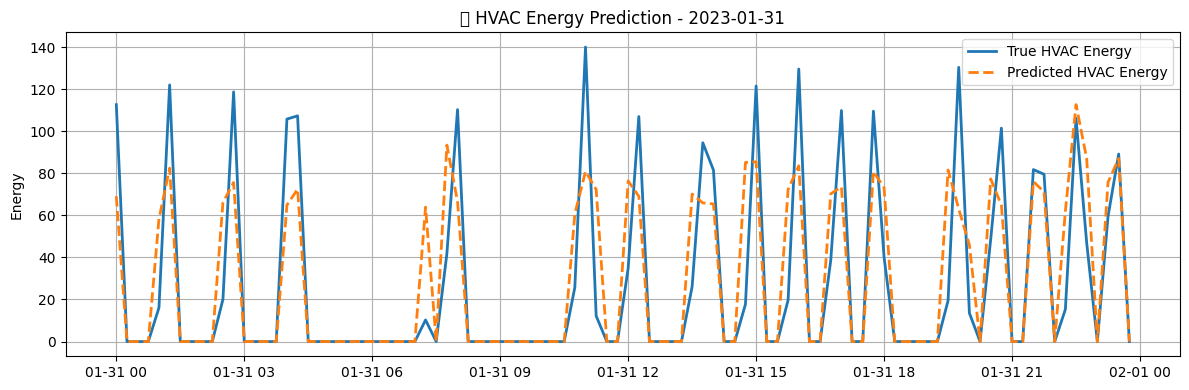

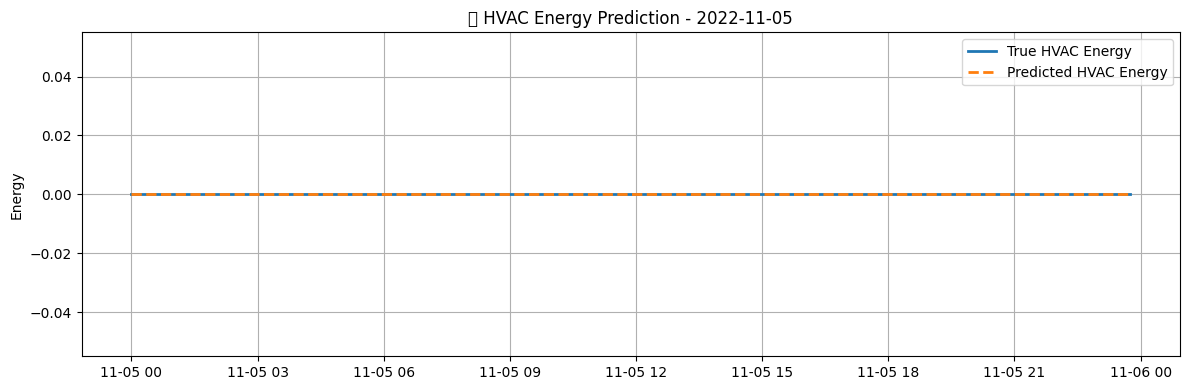

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, classification_report, confusion_matrix
import random

true_energy = df_result['hvac_energy']
pred_energy = df_result['hvac_energy_pred']

r2 = r2_score(true_energy, pred_energy)
rmse = root_mean_squared_error(true_energy, pred_energy)
mae = mean_absolute_error(true_energy, pred_energy)

print("🔍 HVAC Energy Regression Metrics")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")

# --------- MODE CLASSIFICATION METRICS ----------
# true_mode = df_result['hvac_mode_true']
# pred_mode = df_result['hvac_mode']

# print("\n📊 HVAC Mode Classification Report:")
# print(classification_report(true_mode, pred_mode))

# Confusion Matrix
# conf_mat = confusion_matrix(true_mode, pred_mode)
# plt.figure(figsize=(6,5))
# sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
# plt.title("Confusion Matrix (HVAC Modes)")
# plt.xlabel("Predicted Mode")
# plt.ylabel("True Mode")
# plt.tight_layout()
# plt.show()

# --------- RANDOM 2-DAY PLOTS ---------
# Choose 2 random days
unique_days = df_result.index.normalize().unique()
chosen_days = random.sample(list(unique_days), 2)

for day in chosen_days:
    day_mask = (df_result.index.normalize() == day)
    fig, ax1 = plt.subplots(figsize=(12, 4))
    
    ax1.plot(df_result.loc[day_mask].index, df_result.loc[day_mask]['hvac_energy'], label='True HVAC Energy', linewidth=2)
    ax1.plot(df_result.loc[day_mask].index, df_result.loc[day_mask]['hvac_energy_pred'], label='Predicted HVAC Energy', linewidth=2, linestyle='--')
    ax1.set_title(f"🔧 HVAC Energy Prediction - {day.strftime('%Y-%m-%d')}")
    ax1.set_ylabel("Energy")
    ax1.legend()
    ax1.grid(True)
    plt.tight_layout()
    plt.show()

    # fig, ax2 = plt.subplots(figsize=(12, 3))
    # ax2.plot(df_result.loc[day_mask].index, true_mode[day_mask], label='True Mode', drawstyle='steps-post', linewidth=2)
    # ax2.plot(df_result.loc[day_mask].index, pred_mode[day_mask], label='Predicted Mode', drawstyle='steps-post', linestyle='--', linewidth=2)
    # ax2.set_title(f"🎛️ HVAC Mode Classification - {day.strftime('%Y-%m-%d')}")
    # ax2.set_ylabel("Mode")
    # ax2.set_yticks([0, 1, 2])
    # ax2.legend()
    # ax2.grid(True)
    # plt.tight_layout()
    # plt.show()

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_6780\1062203698.py:10: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


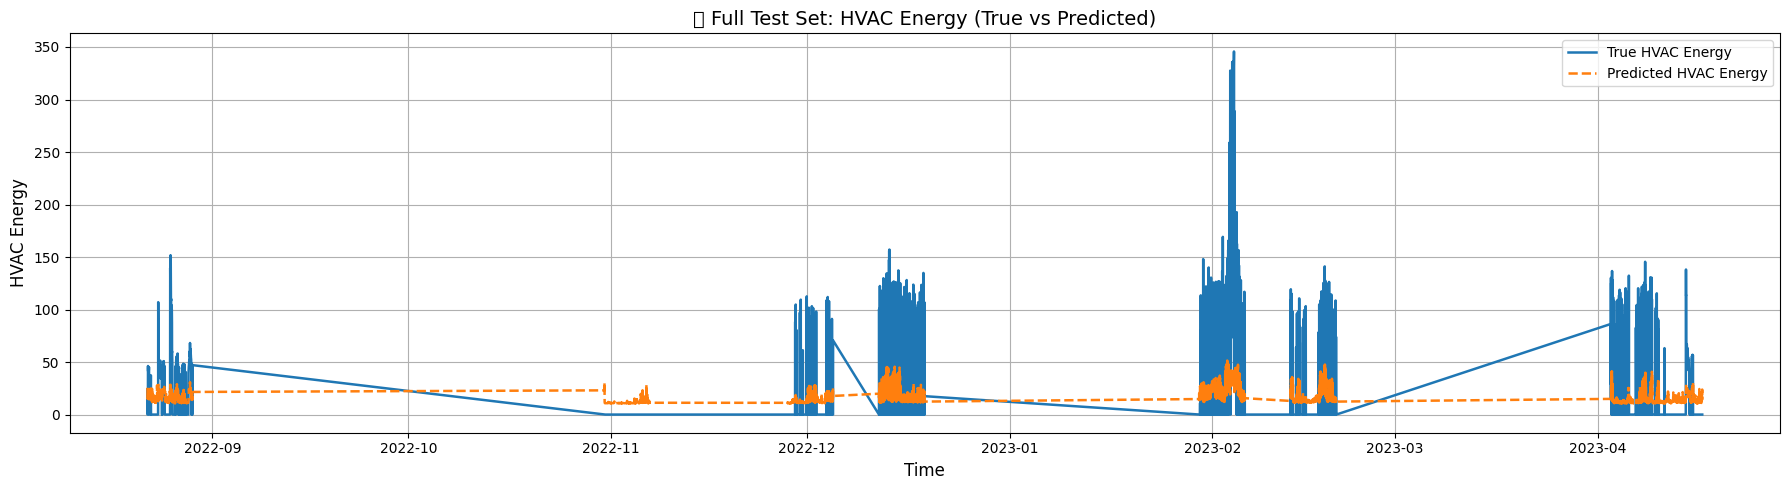

In [45]:

plt.figure(figsize=(18, 5))
plt.plot(df_result.index, df_result['hvac_energy'], label='True HVAC Energy', linewidth=1.8)
plt.plot(df_result.index, df_result['hvac_energy_pred'], label='Predicted HVAC Energy', linestyle='--', linewidth=1.8)

plt.title("📈 Full Test Set: HVAC Energy (True vs Predicted)", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("HVAC Energy", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()